# How the RIO algorithm was derived from the data

This notebook re-derives, from the raw rosbags, every data-driven design decision in the
radar-inertial odometry pipeline. It is the runnable version of the paper's
*Characterization → Methodology* chain, ordered as a forward-told storyline:

| # | Question | Measurement | Design consequence |
|---|----------|-------------|--------------------|
| 1 | What does one radar return mean? | forward model vs MoCap | the radar factor itself, and the estimator-free method used everywhere below |
| 2 | When do measurements arrive? | 10 Hz async frames, timestamp jitter | continuous-time B-spline state (not preintegration between frame states) |
| 3 | How is the noise distributed? | Gaussian core + heavy tails | least-squares with $1/\sigma^2$ weights, Huber $\delta=1.0$ shapes only the tail |
| 4 | Where do the outliers sit? | steep elevation, low SNR | RANSAC prefilter (0.15 m/s), gentle SNR weight |
| 5 | How does noise change with dynamics? | $\sigma(\|\omega\|)$ curves, $\sigma_i/\sigma_c$ split | the $\omega$-adaptive weighting law + $\sigma_c$ whitening |
| 6 | Is aliasing a corner case? | 2 to 38 % of points wrapped | per-frame unwrapping against an IMU-integrated prediction |
| 7 | Is the spline the bottleneck? | representation error vs knot spacing | NO (adaptive-knots no-go); knots are an efficiency lever |
| 8 | Why a sliding window with marginalization? | toy Gaussian demo | Schur marginalization + Markov-blanket rule, prior scale 1.0 universal |
| 9 | Does it all work? | run the deployed solver | the unified flag-free configuration |

**How to run**: kernel = the repo root `.venv` (python 3.12). Runs top to bottom; the load
cell (~1-2 min) caches three bags in memory, chapter 7 takes ~2 min, chapter 9 runs the
real C++ solver (~3-5 min, can be skipped with `RUN_SOLVER = False`).

Sources: each analysis cell is adapted from the scripts that produced the paper numbers
(`analysis/characterize_radar.py`, `characterize_sigma_c_vs_omega.py`,
`characterize_frame_correlation.py`, `adaptive_knots/v1_representation_error.py`); the
paper values are quoted inline so every reproduced number can be cross-checked.

In [1]:
# Setup: repo-relative paths, imports, shared helpers
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'analysis' / 'lib').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('repo root not found (run from inside the repo)')
    REPO_ROOT = REPO_ROOT.parent
ANALYSIS = REPO_ROOT / 'analysis'
for p in (ANALYSIS, ANALYSIS / 'lib', ANALYSIS / 'adaptive_knots'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.signal import butter, filtfilt
from scipy.spatial.transform import Rotation, Slerp
from scipy.stats import linregress

from config_loader import load_config
from rosbag_loader.loader import load_bag_topics, stitch_cpu_counter_resets_improved
from radar_velocity_utils import (compute_doppler_residuals, rotation_matrix_from_euler,
                                  unwrap_doppler, quat_to_rotation_matrix)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'figure.figsize': (12, 4)})

# --- helpers copied from analysis/characterize_radar.py ---
def robust_sigma(x):
    '''1.4826 * MAD: sigma estimate insensitive to heavy tails.'''
    x = np.asarray(x)
    return 1.4826 * np.median(np.abs(x - np.median(x))) if len(x) else np.nan

def binned_sigma(x, residuals, edges, min_n=30):
    centers, sigmas, counts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        if np.sum(m) >= min_n:
            centers.append(0.5 * (lo + hi))
            sigmas.append(robust_sigma(residuals[m]))
            counts.append(int(np.sum(m)))
    return np.array(centers), np.array(sigmas), np.array(counts)

def binned_sigma_bias(x, residuals, edges, min_n=30):
    centers, sigmas, biases, counts = [], [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        if np.sum(m) >= min_n:
            centers.append(0.5 * (lo + hi))
            sigmas.append(robust_sigma(residuals[m]))
            biases.append(float(np.median(residuals[m])))
            counts.append(int(np.sum(m)))
    return np.array(centers), np.array(sigmas), np.array(biases), np.array(counts)

OMEGA_BIN_EDGES = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 14.0])
print(f'repo root: {REPO_ROOT}')

repo root: /home/mouse/MyData/radar-iwr6843-driver


## 0. The datasets and the estimator-free methodology

Three headline flights, one per regime: **slow racing** (gentle), **fast racing**
(aggressive, up to ~5 m/s), **backflips** (sustained flips to ~10 rad/s). Ground truth is
Vicon MoCap; the flight-controller state stream (`agiros_state`) carries the
MoCap-derived position, velocity, orientation and body rate used as the reference.

**The following residual definition is used by every chapter below:** for each radar return we
predict its Doppler *from the MoCap reference through the exact forward model the solver
uses* (bearing, extrinsics, lever arm) and analyze the per-point residual

$$ r = v_\mathrm{meas} - v_\mathrm{pred}(\mathrm{MoCap}). $$

Alias ambiguity is resolved against the ground-truth prediction here
(chapter 6 treats aliasing as its own property). Radar pitch is locked at a measured 27.5 deg.

In [2]:
# Load the three bags and compute per-point Doppler residuals (cached across re-runs)
CFG = load_config()
BAGS_CFG = CFG['bags']['bags']; TIMING = CFG['bags']['timing']
RC = CFG['bags'].get('radar_config', {}); EXT = CFG['extrinsics']

# Deployed extrinsics: pitch locked at the measured 27.5 deg (extrinsics.yaml keeps
# 25.5 only as the batch self-cal seed)
R_BS = rotation_matrix_from_euler(*np.radians([180.0, 27.5, 0.0]))
T_BS = np.array(EXT['translation_body_m'])
RADAR_OFF = EXT['imu_mocap_offset_sec'] - EXT['radar_imu_offset_sec']
IMU_OFF = EXT['imu_mocap_offset_sec']

BAG_KEYS = ['slow_racing_best_velocity', 'fast_racing_best_velocity',
            'backflips_best_velocity']
SHORT = {'slow_racing_best_velocity': 'slow racing',
         'fast_racing_best_velocity': 'fast racing',
         'backflips_best_velocity': 'backflips'}
COLOR = {'slow_racing_best_velocity': 'tab:blue',
         'fast_racing_best_velocity': 'tab:orange',
         'backflips_best_velocity': 'tab:red'}

D = globals().get('D', {})
for key in BAG_KEYS:
    if key in D:
        continue
    v_max = RC.get('best_velocity' if 'best_velocity' in key else 'default',
                   {}).get('v_max', 4.99)
    data = load_bag_topics(str(REPO_ROOT / BAGS_CFG[key]), verbose=False)
    t0 = data.start_time + TIMING[key][0]
    t1 = t0 + TIMING[key][1]
    radar = [f for f in data.radar_velocity
             if t0 <= f.timestamp <= t1 and f.positions is not None]
    imu = [m for m in data.imu_data if t0 <= m.timestamp <= t1]
    states = data.agiros_state          # full range kept for interpolation
    dres = compute_doppler_residuals(states, radar, T_BS, R_BS,
                                     time_offset=RADAR_OFF, min_range=0.2)
    meas, pred = dres['measurements'], dres['predictions']
    unw = unwrap_doppler(meas, pred, v_max)   # ground-truth de-aliased
    r = unw - pred                            # the working residual everywhere below
    fi = np.array(dres['frame_indices']); pi = np.array(dres['point_indices'])
    st_t = np.array([s.timestamp for s in states])
    om_interp = interp1d(st_t, np.array([s.angular_velocity for s in states]),
                         axis=0, kind='linear', bounds_error=False,
                         fill_value='extrapolate')
    t_pts = np.array([radar[i].timestamp for i in fi]) + RADAR_OFF
    om_pts = np.linalg.norm(om_interp(t_pts), axis=1)
    u_z = np.array([radar[f].positions[p][2] / np.linalg.norm(radar[f].positions[p])
                    for f, p in zip(fi, pi)])
    D[key] = dict(v_max=v_max, t0=t0, t1=t1, radar=radar,
                  radar_full=list(data.radar_velocity), imu=imu, states=states,
                  mocap_pose=list(data.mocap_pose), dres=dres, meas=meas, pred=pred,
                  unw=unw, r=r, aliased=(unw != meas), fi=fi, pi=pi, om_pts=om_pts,
                  u_z=u_z, om_interp=om_interp, st_t=st_t)
    del data
    print(f'loaded {key}')

print(f"\n{'bag':<14} {'frames':>7} {'pts/frame':>10} {'frames<5':>9} "
      f"{'IMU rate':>9} {'v_max':>6}")
for key in BAG_KEYS:
    d = D[key]
    ppf = np.array([f.num_points() for f in d['radar']])
    imu_rate = (len(d['imu']) - 1) / (d['imu'][-1].timestamp - d['imu'][0].timestamp)
    print(f"{SHORT[key]:<14} {len(d['radar']):>7} {np.median(ppf):>10.0f} "
          f"{100 * np.mean(ppf < 5):>8.0f}% {imu_rate:>7.0f}Hz {d['v_max']:>6.3f}")
print('\npaper (Table: measured radar data properties): pts/frame 13 / 11 / 10, '
      'frames<5: 6 / 12 / 9 %')

# RANSAC prefilter masks (deployment order: consensus on unwrapped Doppler),
# built once and shared by chapters 3 (ladder), 4 (demo), and 5e.
_rng_masks = np.random.default_rng(0)

def ransac_mask(P, v, thresh=0.15, iters=150):
    n = len(v)
    if n < 5:
        return np.ones(n, dtype=bool)
    Hn = P / np.maximum(np.linalg.norm(P, axis=1, keepdims=True), 1e-6)
    best = None
    for _ in range(iters):
        i3 = _rng_masks.choice(n, 3, replace=False)
        try:
            vc = np.linalg.solve(Hn[i3], v[i3])
        except np.linalg.LinAlgError:
            continue
        inl = np.abs(Hn @ vc - v) < thresh
        if best is None or inl.sum() > best.sum():
            best = inl
    return best if best is not None and best.sum() >= 5 else np.ones(n, dtype=bool)

masks = {}
for key in BAG_KEYS:
    d = D[key]
    masks[key] = {}
    for i, f in enumerate(d['radar']):
        if f.num_points() < 5:
            continue
        v = np.asarray(f.velocities, float).copy()
        sel = d['fi'] == i
        v[d['pi'][sel]] = d['unw'][sel]
        masks[key][i] = ransac_mask(np.asarray(f.positions, float), v)

loaded slow_racing_best_velocity


loaded fast_racing_best_velocity


loaded backflips_best_velocity

bag             frames  pts/frame  frames<5  IMU rate  v_max
slow racing        258         13        6%     993Hz  3.136
fast racing        179         11       12%     993Hz  3.136
backflips          181         10        9%     993Hz  3.136

paper (Table: measured radar data properties): pts/frame 13 / 11 / 10, frames<5: 6 / 12 / 9 %


## 1. Radar forward model

A radar return is a bearing $\mathbf{u}_s$ (unit vector, sensor frame) plus a radial
Doppler velocity $v_d$. For a static world point observed from a moving platform:

$$ v_\mathrm{pred} = -\,\mathbf{u}_b^\top \left( R_{bw}\, \mathbf{v}_w \;+\;
   \boldsymbol{\omega}_b \times \mathbf{t}_{bs} \right), \qquad
   \mathbf{u}_b = R_{bs}\, \mathbf{u}_s $$

with $\mathbf{v}_w$ the platform velocity in world, $R_{bw}$ world-to-body rotation,
$\boldsymbol{\omega}_b \times \mathbf{t}_{bs}$ the lever-arm velocity of the radar
antenna (mounted 8 cm forward, 2 cm left, 1 cm below the body origin), and $R_{bs}$ the
mounting rotation (roll 180 deg, pitch 27.5 deg measured with an inclinometer).

**The minus sign** is the TI convention: positive Doppler = receding target. Flip it and nothing fits (demonstrated below).

slow racing  sigma_rob: correct 0.097   no lever arm 0.095   sign flipped 2.651  (m/s)
fast racing  sigma_rob: correct 0.189   no lever arm 0.185   sign flipped 2.054  (m/s)
backflips    sigma_rob: correct 0.354   no lever arm 0.368   sign flipped 1.494  (m/s)

bag           |L| median   |L| p90  var(no-lever)-var(correct)
slow racing        0.006     0.025                    -0.00043
fast racing        0.027     0.115                    -0.00149
backflips          0.079     0.321                    +0.01030

Reading the lever numbers: the term is signal ~ |omega| x 8.4 cm, but it is
computed from interpolated, jitter-timed MoCap omega, so it also carries an
error. On the racing flights the contribution is tiny (|L| median 0.006-0.027
m/s) and the error cancels the benefit: REMOVING the term even lowers sigma
by ~2%, which is at the edge of statistical resolution (sigma is estimated
to ~1.5% at these point counts). On backflips the contribution reaches
0.3-0.8 m/s and clearly wins: rem

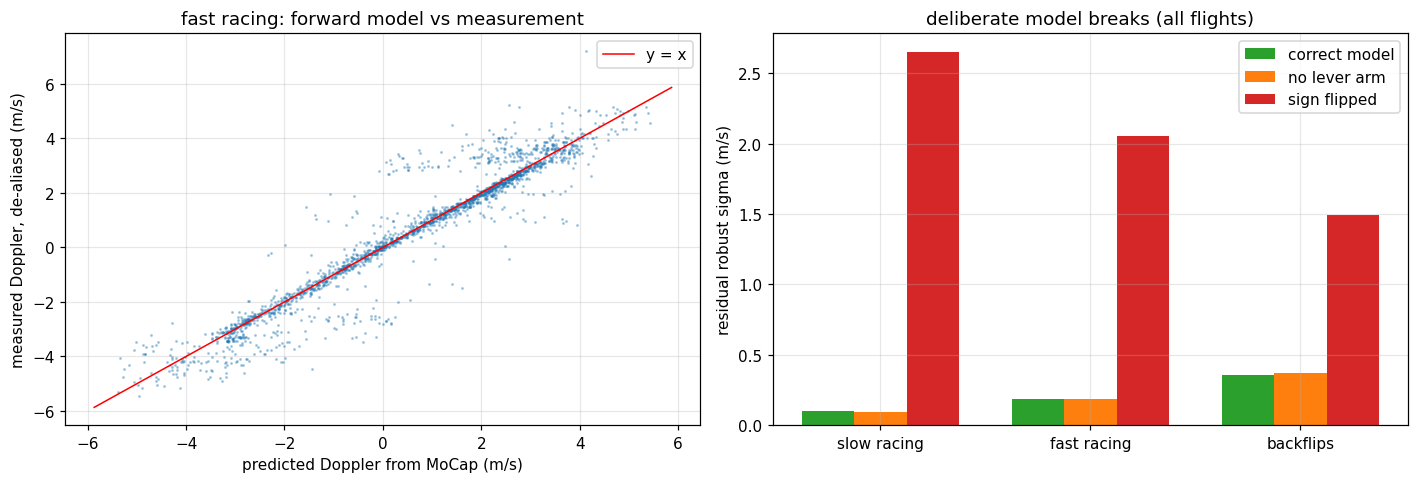

In [3]:
# Forward-model sanity: prediction vs measurement, then two deliberate model
# breaks on ALL flights (flip the Doppler sign; remove the lever arm), plus a
# measurement of the lever term's per-point contribution |L| to see in which
# regime it carries signal.
rows, labels, lever_stats = [], [], []
for key in BAG_KEYS:
    d = D[key]
    s_ok = robust_sigma(d['r'])
    unw_f = unwrap_doppler(d['meas'], -d['pred'], d['v_max'])
    s_flip = robust_sigma(unw_f - (-d['pred']))
    dres_nl = compute_doppler_residuals(d['states'], d['radar'], np.zeros(3), R_BS,
                                        time_offset=RADAR_OFF, min_range=0.2)
    unw_nl = unwrap_doppler(dres_nl['measurements'], dres_nl['predictions'], d['v_max'])
    s_nl = robust_sigma(unw_nl - dres_nl['predictions'])
    L = d['pred'] - dres_nl['predictions']          # the modeled lever contribution
    rows.append([s_ok, s_nl, s_flip]); labels.append(SHORT[key])
    lever_stats.append((np.median(np.abs(L)), np.percentile(np.abs(L), 90),
                        s_nl**2 - s_ok**2))
    print(f"{SHORT[key]:<12} sigma_rob: correct {s_ok:.3f}   no lever arm {s_nl:.3f}   "
          f"sign flipped {s_flip:.3f}  (m/s)")
print()
print(f"{'bag':<12} {'|L| median':>11} {'|L| p90':>9} {'var(no-lever)-var(correct)':>27}")
for lb, (l50, l90, dv) in zip(labels, lever_stats):
    print(f'{lb:<12} {l50:>11.3f} {l90:>9.3f} {dv:>+27.5f}')
print()
print('Reading the lever numbers: the term is signal ~ |omega| x 8.4 cm, but it is')
print('computed from interpolated, jitter-timed MoCap omega, so it also carries an')
print('error. On the racing flights the contribution is tiny (|L| median 0.006-0.027')
print('m/s) and the error cancels the benefit: REMOVING the term even lowers sigma')
print('by ~2%, which is at the edge of statistical resolution (sigma is estimated')
print('to ~1.5% at these point counts). On backflips the contribution reaches')
print('0.3-0.8 m/s and clearly wins: removing it costs +0.010 in variance (~4 sigma')
print('significant). The lever arm is a high-rate feature; it earns its place in')
print('the regime that needs it and costs nothing measurable elsewhere.')

d = D['fast_racing_best_velocity']
sub = np.random.default_rng(0).choice(len(d['pred']), min(4000, len(d['pred'])),
                                      replace=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(d['pred'][sub], d['unw'][sub], '.', ms=2, alpha=0.3)
lim = np.percentile(np.abs(d['pred']), 99.5) * 1.15
axes[0].plot([-lim, lim], [-lim, lim], 'r-', lw=1, label='y = x')
axes[0].set_xlabel('predicted Doppler from MoCap (m/s)')
axes[0].set_ylabel('measured Doppler, de-aliased (m/s)')
axes[0].set_title('fast racing: forward model vs measurement')
axes[0].legend()
x = np.arange(len(labels)); w = 0.25
for i, (name, c) in enumerate([('correct model', 'tab:green'),
                               ('no lever arm', 'tab:orange'),
                               ('sign flipped', 'tab:red')]):
    axes[1].bar(x + (i - 1) * w, [r[i] for r in rows], w, label=name, color=c)
axes[1].set_xticks(x, labels)
axes[1].set_ylabel('residual robust sigma (m/s)')
axes[1].set_title('deliberate model breaks (all flights)')
axes[1].legend()
fig.tight_layout()

> **Design consequence.** Both conventions survive their break test, so the forward
> model as written is justified as the radar factor everywhere downstream. The sign
> flip is catastrophic (sigma 0.10-0.35 to 1.5-2.7 m/s): the TI receding-positive
> convention is settled. The lever arm is a high-rate feature: at racing rates its
> contribution is tiny and its interpolation/timing error cancels the benefit
> (removing it shifts sigma by about -2%, at the edge of statistical resolution),
> while at flip rates the contribution reaches 0.3-0.8 m/s and removing it measurably
> degrades the fit. It earns its place in the regime that needs it and costs nothing
> measurable elsewhere. (In the solver, omega comes from the estimated spline rather
> than interpolated MoCap, so the racing-rate error term there is, if anything,
> smaller.)

## 2. Temporal structure: why a continuous-time spline

Three timing facts decide the estimator architecture before any tuning happens.

Three returns determine a 3D ego-velocity exactly; five is the practical floor
for any outlier-robust per-frame fit. 6-12% of frames are below it.


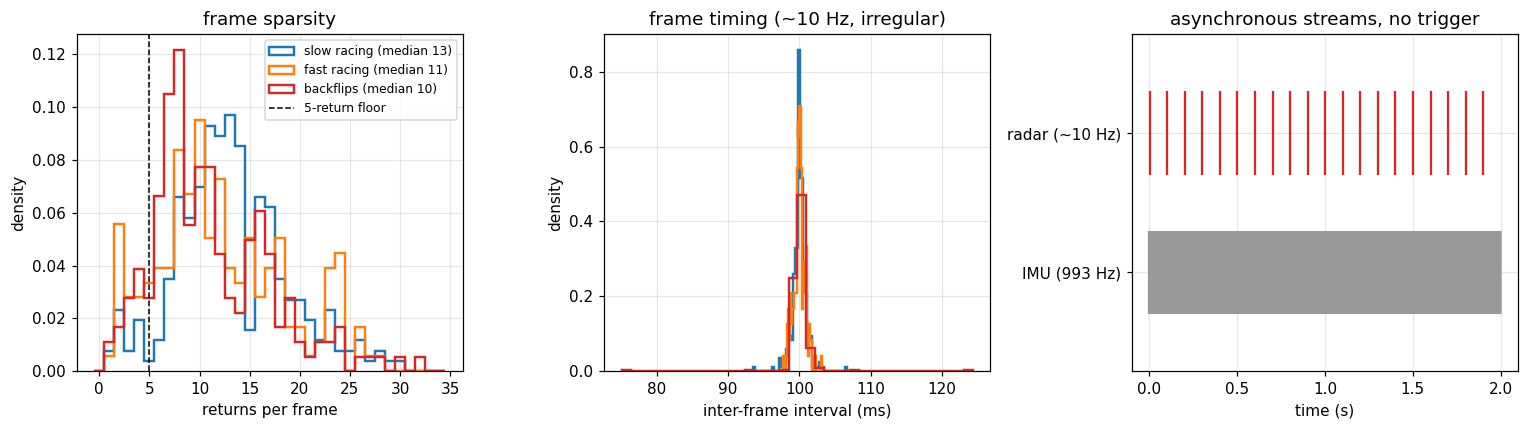

In [4]:
# 2a. Rates and sparsity: 10 Hz radar vs ~1 kHz IMU, and thin frames
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for key in BAG_KEYS:
    d = D[key]
    ppf = np.array([f.num_points() for f in d['radar']])
    axes[0].hist(ppf, bins=np.arange(0, 36) - 0.5, histtype='step', lw=1.6,
                 label=f"{SHORT[key]} (median {np.median(ppf):.0f})",
                 color=COLOR[key], density=True)
    ft = np.array([f.timestamp for f in d['radar']])
    axes[1].hist(1e3 * np.diff(ft), bins=40, histtype='step', lw=1.6,
                 color=COLOR[key], density=True)
axes[0].axvline(5, color='k', ls='--', lw=1, label='5-return floor')
axes[0].set_xlabel('returns per frame'); axes[0].set_ylabel('density')
axes[0].set_title('frame sparsity')
axes[0].legend(fontsize=8)
axes[1].set_xlabel('inter-frame interval (ms)'); axes[1].set_ylabel('density')
axes[1].set_title('frame timing (~10 Hz, irregular)')

# a 2 s slice of arrival times: radar frames vs IMU samples
d = D['fast_racing_best_velocity']
tt0 = d['t0'] + 0.5 * (d['t1'] - d['t0'])   # window midpoint
ft = np.array([f.timestamp for f in d['radar']])
it = np.array([m.timestamp for m in d['imu']])
fsel = ft[(ft >= tt0) & (ft < tt0 + 2)] - tt0
isel = it[(it >= tt0) & (it < tt0 + 2)] - tt0
axes[2].eventplot([isel, fsel], lineoffsets=[0, 1], linelengths=0.6,
                  colors=['0.6', 'tab:red'])
axes[2].set_yticks([0, 1], ['IMU (993 Hz)', 'radar (~10 Hz)'])
axes[2].set_xlabel('time (s)'); axes[2].set_title('asynchronous streams, no trigger')
fig.tight_layout()
print('Three returns determine a 3D ego-velocity exactly; five is the practical floor')
print('for any outlier-robust per-frame fit. 6-12% of frames are below it.')

bag             clock MHz       R^2    sigma  rob sigma     p95     max   kurt


slow racing         200.0  1.000000  1.69ms    0.41ms  1.2ms   36ms  356.9
fast racing         200.0  1.000000  0.73ms    0.58ms  1.3ms    7ms   14.8
backflips           200.0  1.000000  6.62ms    0.82ms  2.1ms  132ms  363.5

paper: jitter sigma 1.7 / 0.7 / 6.6 ms
Distribution: a narrow near-Gaussian core plus sparse one-sided delay
spikes (USB/host scheduling stalls; excess kurtosis far above 0), so the
jitter is NOT Gaussian in the tails; sigma is dominated by the spikes
while the robust sigma shows the well-behaved core.


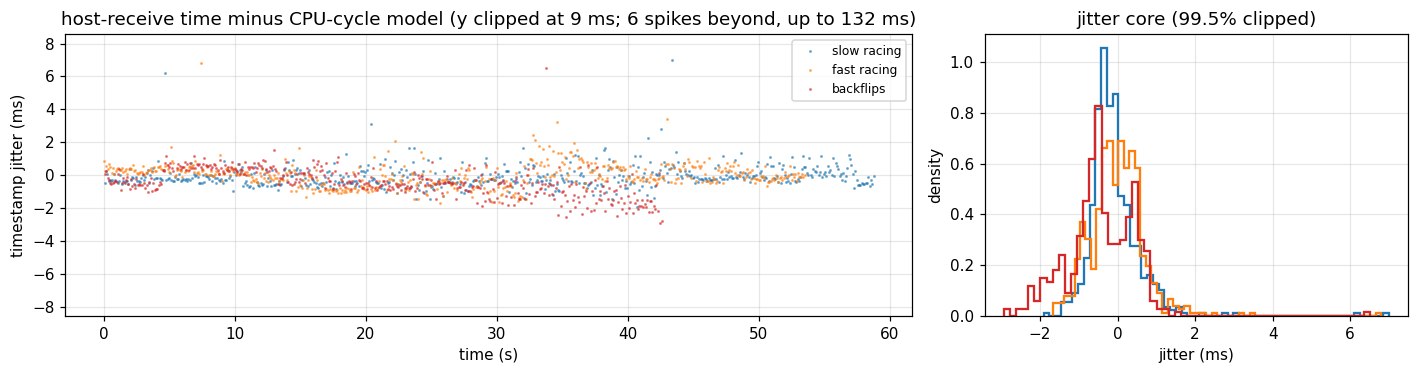

In [5]:
# 2b. Per-frame timestamp jitter, measured from the radar's own CPU-cycle counter
# (regress on-chip cycle count against host receive time; the scatter around the
#  line is the timing jitter of the frame timestamps we are forced to use)
print(f"{'bag':<14} {'clock MHz':>10} {'R^2':>9} {'sigma':>8} {'rob sigma':>10} "
      f"{'p95':>7} {'max':>7} {'kurt':>6}")
jit_save = {}
for key in BAG_KEYS:
    stitched, _ = stitch_cpu_counter_resets_improved(D[key]['radar_full'],
                                                     verbose=False)
    tr = np.array([f.timestamp for f in stitched
                   if f.time_cpu_cycles is not None and len(f.time_cpu_cycles)
                   and f.time_cpu_cycles[0] > 0])
    cc = np.array([f.time_cpu_cycles[0] for f in stitched
                   if f.time_cpu_cycles is not None and len(f.time_cpu_cycles)
                   and f.time_cpu_cycles[0] > 0])
    sl, ic, rv, _, _ = linregress(cc, tr)
    jit = tr - (sl * cc + ic)
    jit_save[key] = (tr, jit)
    print(f"{SHORT[key]:<14} {1/sl/1e6:>10.1f} {rv**2:>9.6f} "
          f"{1e3*np.std(jit):>5.2f}ms {1e3*robust_sigma(jit):>7.2f}ms "
          f"{1e3*np.percentile(np.abs(jit),95):>4.1f}ms "
          f"{1e3*np.max(np.abs(jit)):>4.0f}ms {sp_stats.kurtosis(jit):>6.1f}")
print('\npaper: jitter sigma 1.7 / 0.7 / 6.6 ms')
print('Distribution: a narrow near-Gaussian core plus sparse one-sided delay')
print('spikes (USB/host scheduling stalls; excess kurtosis far above 0), so the')
print('jitter is NOT Gaussian in the tails; sigma is dominated by the spikes')
print('while the robust sigma shows the well-behaved core.')

# y-range clipped to the 99.5% quantile so the core is visible; spikes annotated
allj = np.concatenate([1e3 * j for _, j in jit_save.values()])
ylim = 1.3 * np.percentile(np.abs(allj), 99.5)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5),
                         gridspec_kw={'width_ratios': [2, 1]})
n_clip = 0
for key in BAG_KEYS:
    tr, jit = jit_save[key]
    axes[0].plot(tr - tr[0], 1e3 * jit, '.', ms=2, alpha=0.5, color=COLOR[key],
                 label=SHORT[key])
    n_clip += int(np.sum(np.abs(1e3 * jit) > ylim))
    core = 1e3 * jit[np.abs(1e3 * jit) < ylim]
    axes[1].hist(core, bins=60, histtype='step', lw=1.5, density=True,
                 color=COLOR[key])
axes[0].set_ylim(-ylim, ylim)
axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('timestamp jitter (ms)')
axes[0].set_title(f'host-receive time minus CPU-cycle model '
                  f'(y clipped at {ylim:.0f} ms; {n_clip} spikes beyond, '
                  f'up to {np.max(np.abs(allj)):.0f} ms)')
axes[0].legend(fontsize=8)
axes[1].set_xlabel('jitter (ms)'); axes[1].set_ylabel('density')
axes[1].set_title('jitter core (99.5% clipped)')
fig.tight_layout()

paper: sweep confirms the calibrated offset within 5 ms on the racing flights
(25 ms on backflips, where the minimum is shallow).


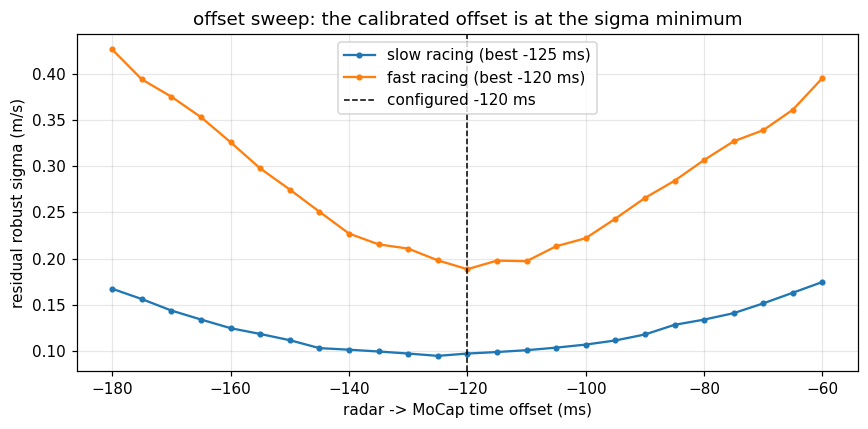

In [6]:
# 2c. The radar-to-MoCap time offset, found by a residual-sigma sweep.
# Why the sigma MINIMUM is the right offset: a misalignment dt adds an error
# term ~ (d v_pred/dt) * dt = radial-jerk-and-accel * dt to every residual,
# statistically independent of the sensor noise, so the spread adds in
# quadrature and is minimized exactly when the clocks align. The faster the
# dynamics, the sharper the minimum (hover data would give a flat curve;
# backflips gives a shallow one because sigma is already dominated by
# flip-regime noise).
fig, ax = plt.subplots(figsize=(8, 4))
for key in ['slow_racing_best_velocity', 'fast_racing_best_velocity']:
    d = D[key]
    offs = RADAR_OFF + np.linspace(-0.06, 0.06, 25)
    sig = []
    for o in offs:
        dd = compute_doppler_residuals(d['states'], d['radar'], T_BS, R_BS,
                                       time_offset=float(o), min_range=0.2)
        ru = unwrap_doppler(dd['measurements'], dd['predictions'], d['v_max']) \
            - dd['predictions']
        sig.append(robust_sigma(ru))
    best = offs[int(np.argmin(sig))]
    ax.plot(1e3 * offs, sig, '-o', ms=3, color=COLOR[key],
            label=f'{SHORT[key]} (best {1e3*best:.0f} ms)')
ax.axvline(1e3 * RADAR_OFF, color='k', ls='--', lw=1,
           label=f'configured {1e3*RADAR_OFF:.0f} ms')
ax.set_xlabel('radar -> MoCap time offset (ms)')
ax.set_ylabel('residual robust sigma (m/s)')
ax.set_title('offset sweep: the calibrated offset is at the sigma minimum')
ax.legend()
fig.tight_layout()
print('paper: sweep confirms the calibrated offset within 5 ms on the racing flights')
print('(25 ms on backflips, where the minimum is shallow).')

> **Design consequence.** Frames are sparse, come at 10 Hz, are not synchronized to the
> IMU, and only frame-level timestamps exist, with 0.7 to 6.6 ms jitter. A
> continuous-time B-spline handles all of that directly: it can be read out at any
> timestamp, gives velocity and body rate in closed form, and needs no preintegration
> around changing biases. The missing per-chirp timestamps return as the flip-regime
> limit in chapters 5 and 7.
>
> *Open lever (checked, not built):* the radar's cycle counter is a much better clock
> than the USB receive time. Using it would remove the measured jitter. Worth roughly
> 0.1 m/s and 4 deg only at backflip rates; nothing on racing.

## 3. The Gaussian core: a discovery story

The first analysis goal in Lukas's feedback mail (`reviewer_feedback_v0.txt`, repo root,
private): *"die Verteilung der Messwerte (Gaussian distributed) mit entsprechender
Ableitung der weights"*. The raw answer is: not Gaussian. The story of this chapter is
how the Gaussian core is *uncovered*: the raw stream's tails turn out to be not noise
but errored measurements from three identifiable mechanisms; removing them rung by rung
(each rung justified by a flag that does not look at the residual, so there is no
circularity) leaves a stream that is Gaussian over the range that matters, plus a small
unflaggable remainder that is exactly what the Huber kernel exists for.

Two spread estimates are used throughout (both quoted in the paper):
$\sigma_\mathrm{rob} = 1.4826 \cdot \mathrm{MAD}$ measures the width of the Gaussian core
and ignores tails; the 1-99 % std still responds to tails. Their gap is itself a tail
measure.

slow racing: Q-Q R^2 inside |z|<1 (~65% of points): 0.9801
fast racing: Q-Q R^2 inside |z|<1 (~61% of points): 0.9884
backflips: Q-Q R^2 inside |z|<1 (~66% of points): 0.9754
The central band is Gaussian-shaped on every flight; everything beyond it is
not. The rest of this chapter finds out what the "everything beyond" is.

bag             sigma_rob  sigma 1-99%  kurtosis  >3sigma  quant bin
slow racing         0.097        0.191      32.0     8.6%      0.049
fast racing         0.189        0.573       6.5    17.8%      0.049
backflips           0.354        0.460       6.8     6.6%      0.049

paper: sigma_rob 0.097 / 0.189 / 0.354, core sigma 0.191 / 0.573 / 0.460,
kurtosis 32.0 / 6.5 / 6.8, >3sigma 8.6 / 17.8 / 6.6 %, bin 0.049 m/s


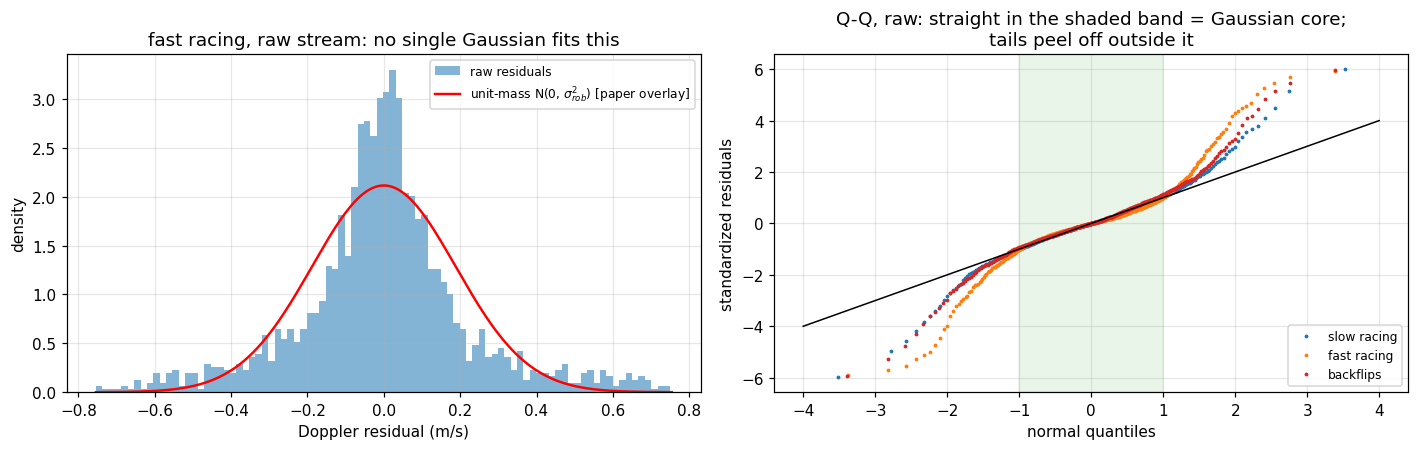

In [7]:
# Rung 0, the raw stream: is the Doppler noise Gaussian? No.
d = D['fast_racing_best_velocity']
rc = d['r'] - np.median(d['r'])
s_mad = robust_sigma(rc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
lim = 4 * s_mad
core = rc[np.abs(rc) < lim]
axes[0].hist(core, bins=90, density=True, alpha=0.55, label='raw residuals')
xg = np.linspace(-lim, lim, 400)
axes[0].plot(xg, sp_stats.norm.pdf(xg, 0, s_mad), 'r-', lw=1.6,
             label='unit-mass N(0, $\\sigma_{rob}^2$) [paper overlay]')
axes[0].set_xlabel('Doppler residual (m/s)'); axes[0].set_ylabel('density')
axes[0].set_title('fast racing, raw stream: no single Gaussian fits this')
axes[0].legend(fontsize=8)

for key in BAG_KEYS:
    dd = D[key]
    sz = robust_sigma(dd['r']); m = np.median(dd['r'])
    z = (dd['r'] - m) / sz
    zc = z[np.abs(z) < 6]
    (osm, osr), _ = sp_stats.probplot(zc, dist='norm', plot=None)
    ii = np.unique(np.linspace(0, len(osm) - 1, 400).astype(int))
    axes[1].plot(osm[ii], osr[ii], '.', ms=3, color=COLOR[key], label=SHORT[key])
axes[1].plot([-4, 4], [-4, 4], 'k-', lw=1)
axes[1].axvspan(-1.0, 1.0, color='tab:green', alpha=0.10)
axes[1].set_xlabel('normal quantiles'); axes[1].set_ylabel('standardized residuals')
axes[1].set_title('Q-Q, raw: straight in the shaded band = Gaussian core;\n'
                  'tails peel off outside it')
axes[1].legend(fontsize=8, loc='lower right')
fig.tight_layout()

for key in BAG_KEYS:
    dd = D[key]
    z = (dd['r'] - np.median(dd['r'])) / robust_sigma(dd['r'])
    zc = z[np.abs(z) < 1.0]
    (osm, osr), (slope, icept, rval) = sp_stats.probplot(zc, dist='norm', plot=None)
    print(f'{SHORT[key]}: Q-Q R^2 inside |z|<1 (~{100*np.mean(np.abs(z)<1.0):.0f}% '
          f'of points): {rval**2:.4f}')
print('The central band is Gaussian-shaped on every flight; everything beyond it is')
print('not. The rest of this chapter finds out what the "everything beyond" is.\n')

print(f"{'bag':<14} {'sigma_rob':>10} {'sigma 1-99%':>12} {'kurtosis':>9} "
      f"{'>3sigma':>8} {'quant bin':>10}")
for key in BAG_KEYS:
    d = D[key]
    r = d['r']
    q1, q99 = np.percentile(r, [1, 99])
    s99 = np.std(r[(r >= q1) & (r <= q99)])
    sz = robust_sigma(r)
    kurt = sp_stats.kurtosis(r)
    fr3 = np.mean(np.abs(r - np.median(r)) > 3 * sz)
    vals = np.sort(np.unique(np.concatenate([np.asarray(f.velocities)
                                             for f in d['radar']])))
    dv = np.diff(vals); dv = dv[dv > 1e-6]
    print(f"{SHORT[key]:<14} {sz:>10.3f} {s99:>12.3f} {kurt:>9.1f} "
          f"{100*fr3:>7.1f}% {np.median(dv):>10.3f}")
print('\npaper: sigma_rob 0.097 / 0.189 / 0.354, core sigma 0.191 / 0.573 / 0.460,')
print('kurtosis 32.0 / 6.5 / 6.8, >3sigma 8.6 / 17.8 / 6.6 %, bin 0.049 m/s')

### Rung S1: remove the aliased returns

Their on-chip bearing was computed from the wrapped velocity (TDM Doppler
compensation) and cannot be repaired; the flag comes from the unwrapper, not from the
residual, so there is no circularity. (Excluded *here* to measure the core; the
deployed treatment is the measured down-weight of chapter 6b, because their Doppler
still carries speed information.)

S1 = S0 minus aliased returns:
  bag              kept  sigma_rob  >3sigma  QQ R2 |z|<3
  slow racing       98%      0.094     7.9%       0.9944
  fast racing       76%      0.138    12.6%       0.9889
  backflips         62%      0.279     6.8%       0.9958


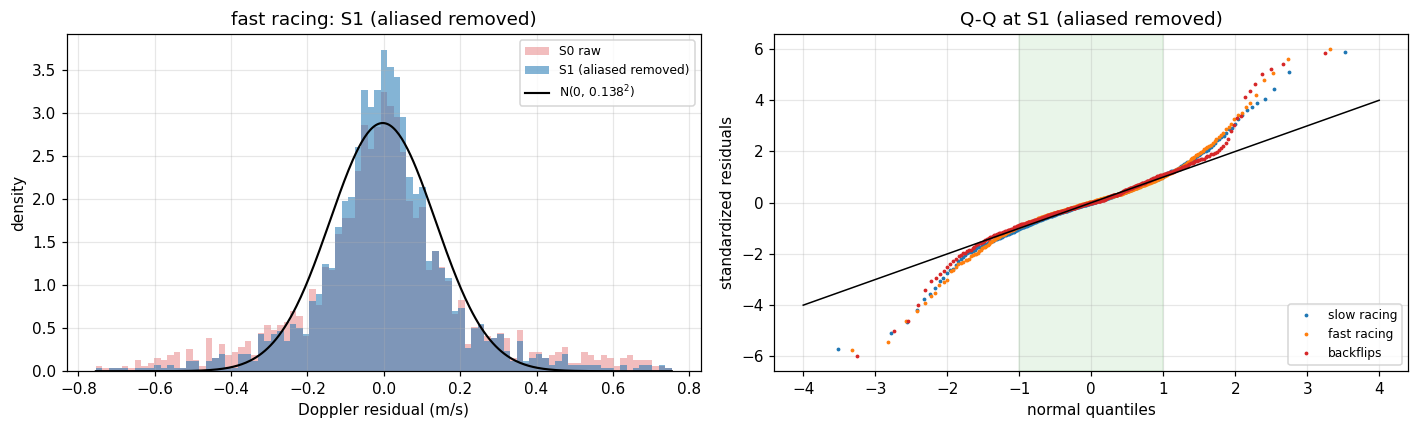

In [8]:
# Rung S1: drop points the unwrapper flagged as aliased
def ladder_stats(r):
    z = (r - np.median(r)) / robust_sigma(r)
    zc = z[np.abs(z) < 3]
    (_, _), (_, _, rv) = sp_stats.probplot(zc, dist='norm', plot=None)
    return len(r), robust_sigma(r), 100*np.mean(np.abs(z) > 3), rv**2

def rung_report(name, SEL):
    print(f"{name}:")
    print(f"  {'bag':<14} {'kept':>6} {'sigma_rob':>10} {'>3sigma':>8} {'QQ R2 |z|<3':>12}")
    for key in BAG_KEYS:
        d = D[key]
        n, sz, f3, r2 = ladder_stats(d['r'][SEL[key]])
        print(f"  {SHORT[key]:<14} {100*n/len(d['r']):>5.0f}% {sz:>10.3f} {f3:>7.1f}% {r2:>12.4f}")

def rung_plot(SEL, title):
    d = D['fast_racing_best_velocity']
    rr = d['r'] - np.median(d['r'])
    rk = rr[SEL['fast_racing_best_velocity']]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    lim = 4 * robust_sigma(rr)
    bins = np.linspace(-lim, lim, 90)
    axes[0].hist(rr[np.abs(rr) < lim], bins=bins, density=True, alpha=0.30,
                 color='tab:red', label='S0 raw')
    axes[0].hist(rk[np.abs(rk) < lim], bins=bins, density=True, alpha=0.55,
                 color='tab:blue', label=title)
    sz = robust_sigma(rk)
    xg = np.linspace(-lim, lim, 400)
    axes[0].plot(xg, sp_stats.norm.pdf(xg, np.median(rk), sz), 'k-', lw=1.4,
                 label=f'N(0, {sz:.3f}$^2$)')
    axes[0].set_xlabel('Doppler residual (m/s)'); axes[0].set_ylabel('density')
    axes[0].set_title(f'fast racing: {title}')
    axes[0].legend(fontsize=8)
    for key in BAG_KEYS:
        dd = D[key]
        rb = dd['r'][SEL[key]]
        z = (rb - np.median(rb)) / robust_sigma(rb)
        zc = z[np.abs(z) < 6]
        (osm, osr), _ = sp_stats.probplot(zc, dist='norm', plot=None)
        ii = np.unique(np.linspace(0, len(osm) - 1, 400).astype(int))
        axes[1].plot(osm[ii], osr[ii], '.', ms=3, color=COLOR[key], label=SHORT[key])
    axes[1].plot([-4, 4], [-4, 4], 'k-', lw=1)
    axes[1].axvspan(-1.0, 1.0, color='tab:green', alpha=0.10)
    axes[1].set_xlabel('normal quantiles'); axes[1].set_ylabel('standardized residuals')
    axes[1].set_title(f'Q-Q at {title}')
    axes[1].legend(fontsize=8, loc='lower right')
    fig.tight_layout()

SEL1 = {key: ~D[key]['aliased'] for key in BAG_KEYS}
rung_report('S1 = S0 minus aliased returns', SEL1)
rung_plot(SEL1, 'S1 (aliased removed)')

### Rung S2: remove points from thin frames

Frames with fewer than five returns leave no redundancy: three returns determine a 3-DoF
ego-velocity exactly, so no consensus test can vet them. (Deployed counterpart: these
frames bypass the prefilter, and the Huber backstop is their only protection.)

S2 = S1 minus thin-frame points:
  bag              kept  sigma_rob  >3sigma  QQ R2 |z|<3
  slow racing       97%      0.095     7.8%       0.9948
  fast racing       74%      0.143    12.4%       0.9883
  backflips         60%      0.283     6.9%       0.9958


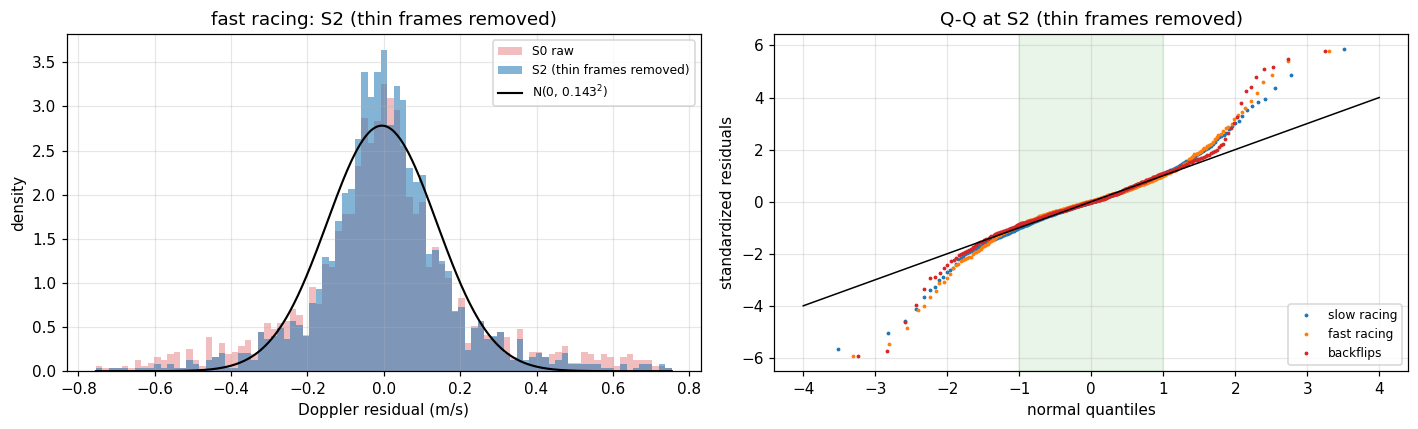

In [9]:
# Rung S2: additionally drop points from frames with < 5 returns
SEL2 = {}
for key in BAG_KEYS:
    d = D[key]
    thin = np.array([d['radar'][i].num_points() < 5 for i in d['fi']])
    SEL2[key] = SEL1[key] & ~thin
rung_report('S2 = S1 minus thin-frame points', SEL2)
rung_plot(SEL2, 'S2 (thin frames removed)')

### Rung S3: remove the consensus rejects

Points that no rigid ego-motion hypothesis explains, found by the same seeded RANSAC the
solver deploys (chapter 4), running on unwrapped Doppler in deployment order. This is
the one rung the deployed front end executes as deletion.

S3 = S2 minus consensus rejects:
  bag              kept  sigma_rob  >3sigma  QQ R2 |z|<3
  slow racing       88%      0.086     2.8%       0.9967
  fast racing       60%      0.113     5.3%       0.9947
  backflips         48%      0.244     2.0%       0.9972

The racing core widths CONVERGE after the ladder (0.086 / 0.113): one
underlying sensor noise, plus regime-dependent identifiable contamination
(backflips stays higher by exactly the chapter-5 rate law).


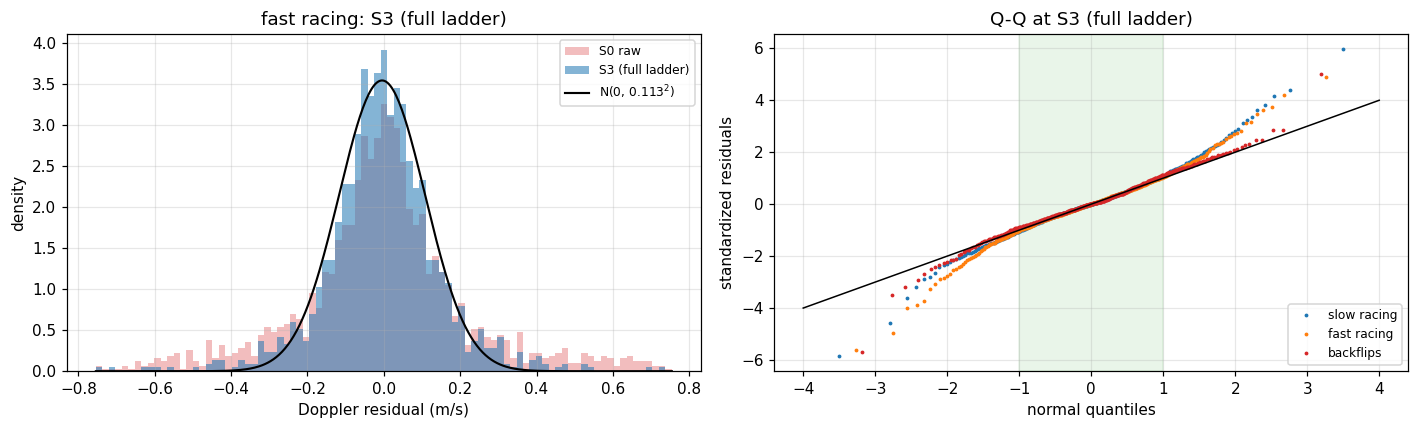

In [10]:
# Rung S3: additionally drop RANSAC-rejected points (deployment front end)
S3_SEL = {}
for key in BAG_KEYS:
    d = D[key]
    ok = np.ones(len(d['r']), bool)
    for i, m in masks[key].items():
        sel = d['fi'] == i
        for j in np.where(sel)[0]:
            if d['pi'][j] < len(m):
                ok[j] = m[d['pi'][j]]
    S3_SEL[key] = SEL2[key] & ok
rung_report('S3 = S2 minus consensus rejects', S3_SEL)
print()
print('The racing core widths CONVERGE after the ladder (0.086 / 0.113): one')
print('underlying sensor noise, plus regime-dependent identifiable contamination')
print('(backflips stays higher by exactly the chapter-5 rate law).')
rung_plot(S3_SEL, 'S3 (full ladder)')

Two checks that the ladder is the right tool and not a trick:

1. **Rescaling cannot do this.** Standardizing every point by its measured rate-law
   sigma or its SNR-decile sigma leaves the tails unchanged (tested; kurtosis and tail
   mass move by noise only). The non-Gaussianity is discrete contamination, not
   heteroscedasticity.
2. **Kurtosis is not the endpoint statistic.** Deleting tail mass shrinks sigma, so
   the few unflagged survivors count as 10-25 sigma events and kurtosis explodes even
   as the stream gets cleaner. Tail fraction and Q-Q straightness are the honest
   metrics.

Honest endpoint: 2.6-5.3% of S3 points still sit beyond 3 sigma (a clean
Gaussian would have 0.3%). No flag we have identifies them (candidates:
multipath ghosts, moving-prop reflections, reference error). That
remainder is precisely what the Huber kernel exists for -- next cell.


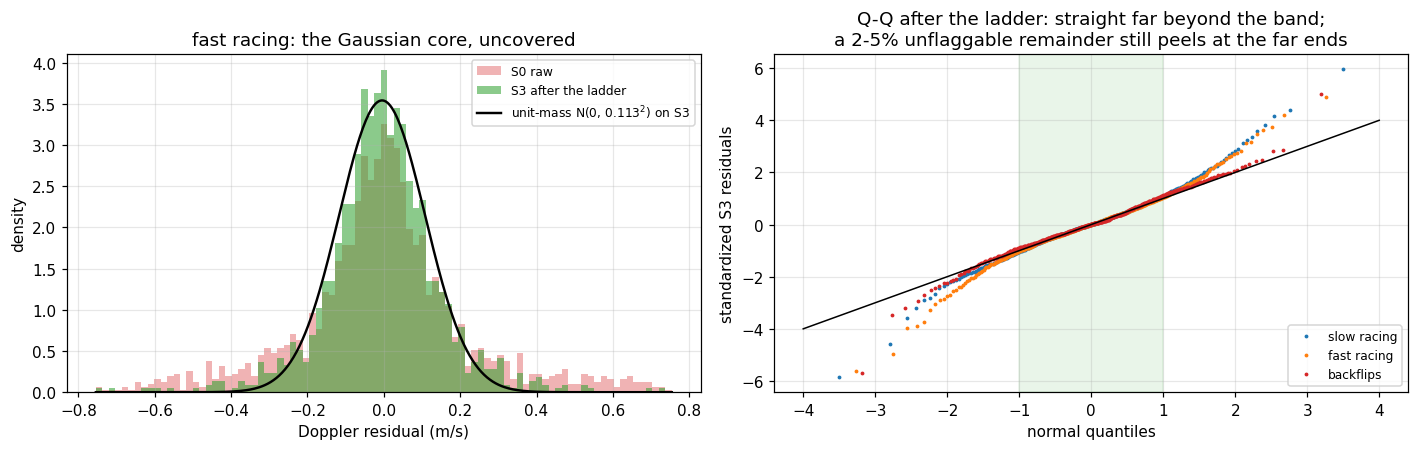

In [11]:
# The payoff: the same overlay that failed on the raw stream fits the remainder.
d = D['fast_racing_best_velocity']
rc = d['r'] - np.median(d['r'])
r3 = rc[S3_SEL['fast_racing_best_velocity']]
s3 = robust_sigma(r3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
lim = 4 * robust_sigma(rc)
bins = np.linspace(-lim, lim, 90)
axes[0].hist(rc[np.abs(rc) < lim], bins=bins, density=True, alpha=0.35,
             color='tab:red', label='S0 raw')
axes[0].hist(r3[np.abs(r3) < lim], bins=bins, density=True, alpha=0.55,
             color='tab:green', label='S3 after the ladder')
xg = np.linspace(-lim, lim, 400)
axes[0].plot(xg, sp_stats.norm.pdf(xg, np.median(r3), s3), 'k-', lw=1.6,
             label=f'unit-mass N(0, {s3:.3f}$^2$) on S3')
axes[0].set_xlabel('Doppler residual (m/s)'); axes[0].set_ylabel('density')
axes[0].set_title('fast racing: the Gaussian core, uncovered')
axes[0].legend(fontsize=8)

for key in BAG_KEYS:
    dd = D[key]
    rr = dd['r'] - np.median(dd['r'])
    r3b = rr[S3_SEL[key]]
    z = (r3b - np.median(r3b)) / robust_sigma(r3b)
    zc = z[np.abs(z) < 6]
    (osm, osr), _ = sp_stats.probplot(zc, dist='norm', plot=None)
    ii = np.unique(np.linspace(0, len(osm) - 1, 400).astype(int))
    axes[1].plot(osm[ii], osr[ii], '.', ms=3, color=COLOR[key], label=SHORT[key])
axes[1].plot([-4, 4], [-4, 4], 'k-', lw=1)
axes[1].axvspan(-1.0, 1.0, color='tab:green', alpha=0.10)
axes[1].set_xlabel('normal quantiles'); axes[1].set_ylabel('standardized S3 residuals')
axes[1].set_title('Q-Q after the ladder: straight far beyond the band;\n'
                  'a 2-5% unflaggable remainder still peels at the far ends')
axes[1].legend(fontsize=8, loc='lower right')
fig.tight_layout()
print('Honest endpoint: 2.6-5.3% of S3 points still sit beyond 3 sigma (a clean')
print('Gaussian would have 0.3%). No flag we have identifies them (candidates:')
print('multipath ghosts, moving-prop reflections, reference error). That')
print('remainder is precisely what the Huber kernel exists for -- next cell.')

**The story is the solver.** Every rung of the ladder maps onto a deployed mechanism,
so the characterization above and the shipped pipeline are one object, not two:

| Ladder finding | Deployed mechanism | Where |
|---|---|---|
| S1 aliased returns (bearing broken, Doppler recoverable, error floor 0.6 m/s) | causal down-weight $w(\|\omega\|)$, not deletion (measured: their speed information is worth keeping) | ch. 6b, driver default |
| S2 thin frames (no consensus possible) | prefilter bypass; Huber is their only protection | ch. 4 |
| S3 consensus rejects (no rigid ego-motion explains them) | RANSAC deletion | ch. 4 |
| unflaggable 2-5 % remainder | Huber bounded influence | below |
| the Gaussian core itself | $1/\sigma^2$ weights with derived statics, rate law, SNR clip, $\sigma_c$ whitening | ch. 5, 5e |

Because the aliased rung is deployed as a $w \le 0.28$ down-weight rather than
deletion, the likelihood the solver optimizes is, to within that weight, exactly the
S3 core uncovered above plus the Huber-bounded remainder: no fork between the story
and the shipped estimator.

bag            delta/sigma_S3  raw beyond delta  S3 beyond delta
slow racing             11.6x             2.66%            0.03%
fast racing              8.9x            11.48%            1.55%
backflips                4.1x             7.18%            1.13%

Sanity: delta sits 3.6-11x above the post-ladder core (vs 1.345x for a
textbook efficiency kernel) and 20x the 0.049 m/s quantization bin: it
shapes only the tail, never the fit. Same design for the accelerometer
(delta_a = 2.0 m/s^2 vs in-band residual 0.45-1.1 = 1.8-4.4x). Ablation
at the deployed weights: removing Huber is bit-par on slow (it touches
0.03% of kept points) but costs fast racing drift 1.17 -> 1.45%.


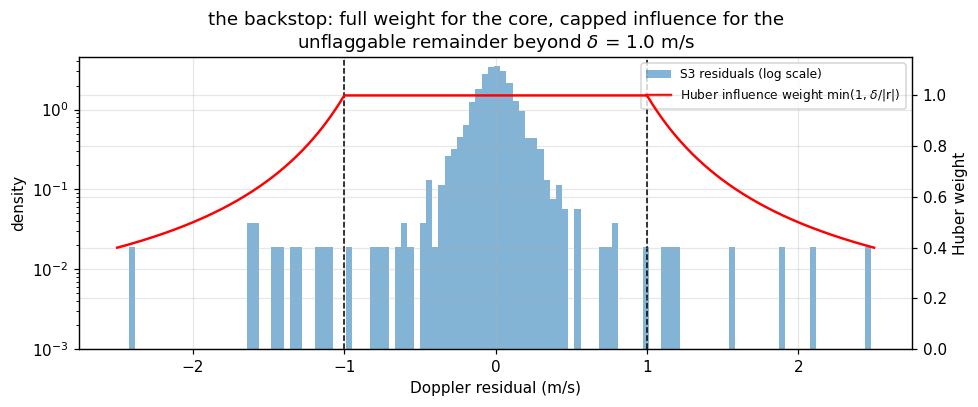

In [12]:
# Huber: the backstop for the unflaggable remainder + a brief parameter sanity
# check. delta = 1.0 m/s is deliberately NOT an efficiency-tuned M-estimator
# (that convention would be delta ~ 1.345 sigma); it is a wide backstop that
# leaves the core strictly quadratic and only caps what the ladder cannot flag.
print(f"{'bag':<14} {'delta/sigma_S3':>14} {'raw beyond delta':>17} {'S3 beyond delta':>16}")
for key in BAG_KEYS:
    d = D[key]
    rr = d['r'] - np.median(d['r'])
    r3 = rr[S3_SEL[key]]
    print(f'{SHORT[key]:<14} {1.0/robust_sigma(r3):>13.1f}x '
          f'{100*np.mean(np.abs(rr) > 1.0):>16.2f}% {100*np.mean(np.abs(r3) > 1.0):>15.2f}%')
print()
print('Sanity: delta sits 3.6-11x above the post-ladder core (vs 1.345x for a')
print('textbook efficiency kernel) and 20x the 0.049 m/s quantization bin: it')
print('shapes only the tail, never the fit. Same design for the accelerometer')
print('(delta_a = 2.0 m/s^2 vs in-band residual 0.45-1.1 = 1.8-4.4x). Ablation')
print('at the deployed weights: removing Huber is bit-par on slow (it touches')
print('0.03% of kept points) but costs fast racing drift 1.17 -> 1.45%.')

d = D['fast_racing_best_velocity']
rr = d['r'] - np.median(d['r'])
r3 = rr[S3_SEL['fast_racing_best_velocity']]
fig, ax = plt.subplots(figsize=(9, 3.8))
lim = 2.5
ax.hist(r3[np.abs(r3) < lim], bins=120, density=True, alpha=0.55,
        label='S3 residuals (log scale)')
ax.set_yscale('log'); ax.set_ylim(1e-3, None)
ax2 = ax.twinx()
xg = np.linspace(-lim, lim, 500)
ax2.plot(xg, np.minimum(1.0, 1.0/np.maximum(np.abs(xg), 1e-9)), 'r-', lw=1.6,
         label='Huber influence weight min(1, $\\delta$/|r|)')
ax2.set_ylim(0, 1.15); ax2.set_ylabel('Huber weight')
ax.axvline(1.0, color='k', ls='--', lw=1); ax.axvline(-1.0, color='k', ls='--', lw=1)
ax.set_xlabel('Doppler residual (m/s)'); ax.set_ylabel('density')
ax.set_title('the backstop: full weight for the core, capped influence for the\n'
             'unflaggable remainder beyond $\\delta$ = 1.0 m/s')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
fig.tight_layout()

tail statistics, fast racing (per-point):
  model                         excess kurtosis  frac |z|>3
  one global sigma                          6.5       17.8%
  whitened sigma(|omega|)                   7.7       16.9%
  (backflips, same test: kurt 6.8 -> 8.3, tails 6.6 -> 7.0%. The scale-
  mixture explanation of the heavy marginal is REJECTED: the core width
  varies with regime exactly as chapter 5 measures, but the tails
  survive any per-point rescaling because they are not scale noise.)

  tail structure (366 points with |z|>3 after whitening):
  category                      base rate   in tail  enrichment
  aliased                           23.7%     55.5%        2.3x
  steep elevation |u_z|>0.5         38.5%     35.8%        0.9x
  high rate |omega|>4                8.9%     10.4%        1.2x
  lowest-quintile intensity         19.5%     26.0%        1.3x


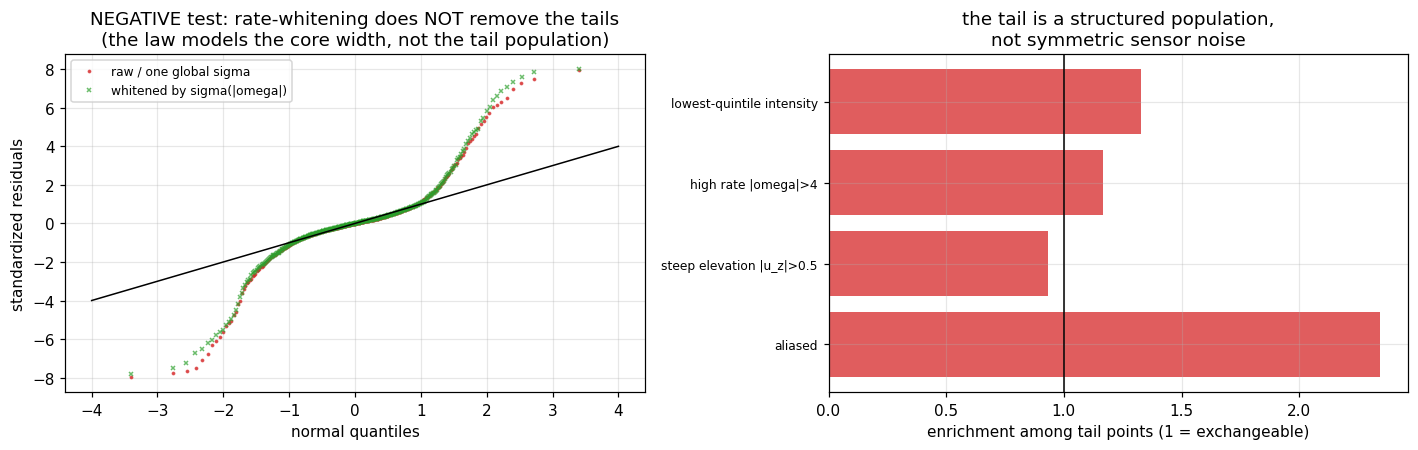

In [13]:
# What the tails ARE: two final diagnostics on the raw stream.
# (i) a deliberate NEGATIVE test of the scale-mixture explanation, (ii) the
# tail population's identity card (enrichment of the ladder's flags).
d = D['fast_racing_best_velocity']
rc = d['r'] - np.median(d['r'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# (ii) TEST: are the tails just pooled regimes (a scale mixture)? Whiten by
# the ch.5 rate law (omega_0 = 4 here; the test is insensitive to 4 vs 4.5)
# and re-check. Expected if true: kurtosis and tail
# fraction drop. Measured: they do NOT (also true on backflips, where |omega|
# actually spans the law: kurt 6.8 -> 8.3). The law models the CORE width
# (chapter 5 fits it on the within-frame component); the tails are something
# else entirely.
om = d['om_pts']
sigma0 = robust_sigma(rc[om < 1.0])
z_raw = rc / robust_sigma(rc)
z_wht = rc / (sigma0 * np.sqrt(1 + (om / 4.0) ** 2))
z_wht = z_wht / robust_sigma(z_wht)
for z, col, mk, name in [(z_raw, 'tab:red', '.', 'raw / one global sigma'),
                         (z_wht, 'tab:green', 'x', 'whitened by sigma(|omega|)')]:
    zc = z[np.abs(z) < 8]
    (qq, vv), _ = sp_stats.probplot(zc, dist='norm', plot=None)
    ii = np.unique(np.linspace(0, len(qq) - 1, 400).astype(int))
    axes[0].plot(qq[ii], vv[ii], mk, ms=3, color=col, label=name, alpha=0.7)
axes[0].plot([-4, 4], [-4, 4], 'k-', lw=1)
axes[0].set_xlabel('normal quantiles'); axes[0].set_ylabel('standardized residuals')
axes[0].set_title('NEGATIVE test: rate-whitening does NOT remove the tails\n'
                  '(the law models the core width, not the tail population)')
axes[0].legend(fontsize=8)

print('tail statistics, fast racing (per-point):')
print(f"  {'model':<28} {'excess kurtosis':>16} {'frac |z|>3':>11}")
for z, name in [(z_raw, 'one global sigma'), (z_wht, 'whitened sigma(|omega|)')]:
    print(f'  {name:<28} {sp_stats.kurtosis(z):>16.1f} '
          f'{100*np.mean(np.abs(z) > 3):>10.1f}%')
print('  (backflips, same test: kurt 6.8 -> 8.3, tails 6.6 -> 7.0%. The scale-')
print('  mixture explanation of the heavy marginal is REJECTED: the core width')
print('  varies with regime exactly as chapter 5 measures, but the tails')
print('  survive any per-point rescaling because they are not scale noise.)')

# (iii) is the surviving tail exchangeable noise? enrichment of identifiable
# causes among |z|>3 points (vs their base rate in all points)
tail = np.abs(z_wht) > 3
inten = d['dres']['intensities']
cats = {'aliased': d['aliased'],
        'steep elevation |u_z|>0.5': np.abs(d['u_z']) > 0.5,
        'high rate |omega|>4': om > 4.0,
        'lowest-quintile intensity': inten < np.percentile(inten, 20)}
print(f"\n  tail structure ({tail.sum()} points with |z|>3 after whitening):")
print(f"  {'category':<28} {'base rate':>10} {'in tail':>9} {'enrichment':>11}")
labels, enr = [], []
for name, m in cats.items():
    base, intail = np.mean(m), np.mean(m[tail])
    labels.append(name); enr.append(intail / max(base, 1e-9))
    print(f'  {name:<28} {100*base:>9.1f}% {100*intail:>8.1f}% {enr[-1]:>10.1f}x')
axes[1].barh(np.arange(len(labels)), enr, color='tab:red', alpha=0.75)
axes[1].axvline(1.0, color='k', lw=1)
axes[1].set_yticks(np.arange(len(labels)), labels, fontsize=8)
axes[1].set_xlabel('enrichment among tail points (1 = exchangeable)')
axes[1].set_title('the tail is a structured population,\nnot symmetric sensor noise')
fig.tight_layout()

> **Design consequence.** The story in one breath: the raw stream is not Gaussian; its
> tails are errored measurements from three identifiable mechanisms (aliased bearings,
> unvettable thin frames, consensus rejects); removing them uncovers a Gaussian core
> whose width converges across the racing regimes; a 2-5 % unflaggable remainder stays,
> and that remainder, not the core, is what Huber bounds. The weights use the core
> ($1/\sigma^2$, chapter 5e derives them), the front end implements the ladder's rungs
> that are computable without ground truth (chapter 4), and Huber's $\delta = 1.0$ m/s
> is a wide backstop, deliberately not an efficiency kernel. A Student-t likelihood was
> considered and rejected: it treats errored measurements as valid data with big noise,
> and our bad points come in agreeing clusters and carry bias under flips; the GNC
> (redescending-loss) experiment confirmed this end-to-end.

## 4. Outlier structure: where the error lives, and the consensus prefilter

Chapter 3 flagged outlier populations by mechanism. This chapter maps how the radar
error varies across the sensor's rays, the flight regime, and signal strength, and
shows the front end that removes outliers before the solve: 4a bias and noise by
elevation, 4b by intensity, 4c the per-frame consensus test, 4d the threshold
trade-off with both failure edges measured.

paper: racing median residual within +-0.06 m/s at every elevation (biased NO);
sigma roughly DOUBLES at the steep down-looking end (u_z ~ -0.9) while the
up-looking side stays flat (racing rarely paints steep up-looking rays).
Under sustained flips, sigma is elevated at both extremes AND steep up-looking
rays acquire the +0.69 m/s systematic. So the elevation-correlated error is a
FLIGHT-REGIME effect, not an antenna constant. This is why we keep steep rays
(sole carriers of vertical velocity) and treat the flip-regime bias separately.


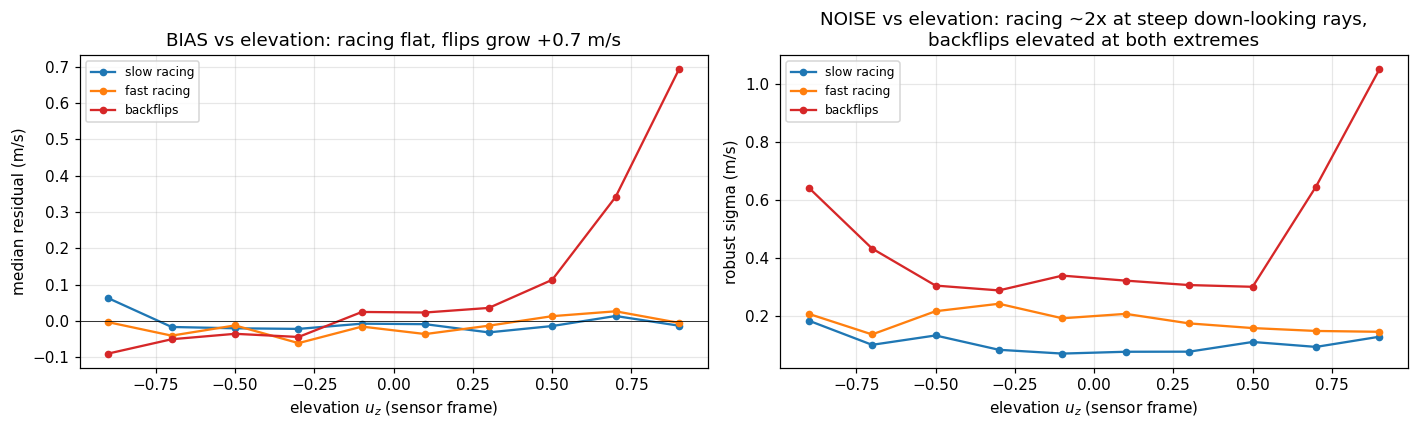

In [14]:
# 4a. Residual bias and sigma vs elevation angle (sensor-frame u_z of the ray)
uz_edges = np.linspace(-1.0, 1.0, 11)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for key in BAG_KEYS:
    d = D[key]
    c, s, b, n = binned_sigma_bias(d['u_z'], d['r'], uz_edges)
    axes[0].plot(c, b, '-o', ms=4, color=COLOR[key], label=SHORT[key])
    axes[1].plot(c, s, '-o', ms=4, color=COLOR[key], label=SHORT[key])
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('elevation $u_z$ (sensor frame)')
axes[0].set_ylabel('median residual (m/s)')
axes[0].set_title('BIAS vs elevation: racing flat, flips grow +0.7 m/s')
axes[1].set_xlabel('elevation $u_z$ (sensor frame)')
axes[1].set_ylabel('robust sigma (m/s)')
axes[1].set_title('NOISE vs elevation: racing ~2x at steep down-looking rays,\n'
                  'backflips elevated at both extremes')
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
print('paper: racing median residual within +-0.06 m/s at every elevation (biased NO);')
print('sigma roughly DOUBLES at the steep down-looking end (u_z ~ -0.9) while the')
print('up-looking side stays flat (racing rarely paints steep up-looking rays).')
print('Under sustained flips, sigma is elevated at both extremes AND steep up-looking')
print('rays acquire the +0.69 m/s systematic. So the elevation-correlated error is a')
print('FLIGHT-REGIME effect, not an antenna constant. This is why we keep steep rays')
print('(sole carriers of vertical velocity) and treat the flip-regime bias separately.')

FINDING: high-intensity returns are consistently the quietest; the trend is
noisy at low intensity but the strongest decile is the quietest on every bag:
  slow racing  sigma weakest/peak/strongest decile 0.084/0.114/0.074
  fast racing  sigma weakest/peak/strongest decile 0.177/0.288/0.111
  backflips    sigma weakest/peak/strongest decile 0.308/0.442/0.293

CONSEQUENCE: weight w = (I/I_med)^alpha with alpha = 1, the inverse-variance
choice for sigma^2 ~ 1/I, relative to the FRAME median so a frame's total
radar weight is unchanged. The dots are the weights the measured noise
implies; the line is what the law assigns. Fitting the exponent to the dots
gives alpha_hat = 0.61 pooled (slow racing 0.56, fast racing 1.03, backflips 0.25): alpha = 1
matches fast racing, the bag with the widest SNR span; slow and backflips
imply flatter curves because their noise is regime-dominated, not
intensity-dominated. A confound-controlled alpha derivation is a recorded
refinement.

The solver applies 

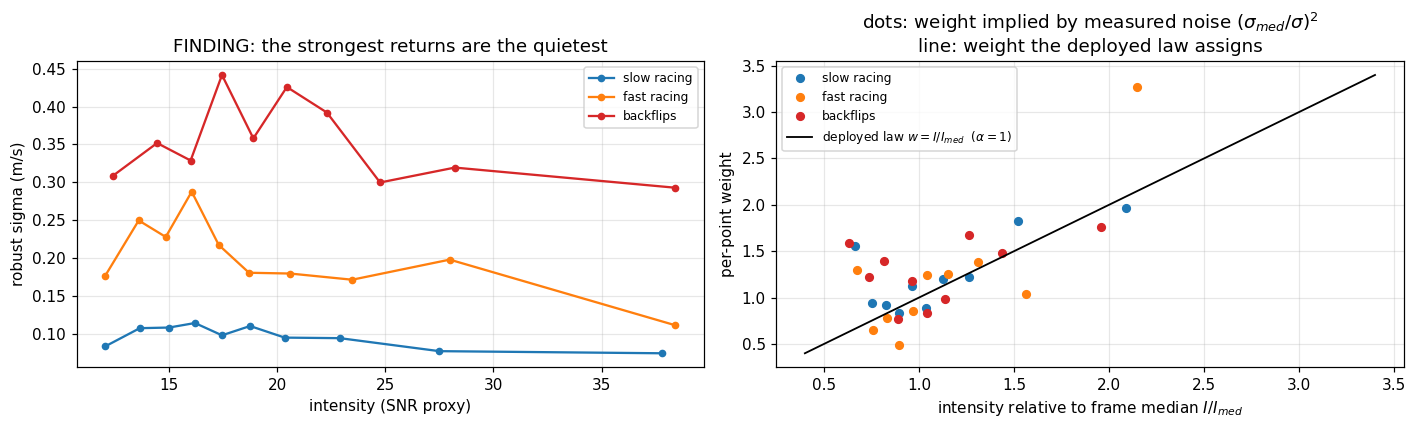

In [15]:
# 4b. Signal strength. Finding: strong returns are quieter. Consequence: weight
# each point by its intensity relative to the frame median (inverse variance).
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
span_txt, alpha_txt, logx, logy, w_pts = [], [], [], [], []
for key in BAG_KEYS:
    d = D[key]
    inten = d['dres']['intensities']
    i_edges = np.unique(np.percentile(inten, np.linspace(0, 100, 11)))
    c, s, n = binned_sigma(inten, d['r'], i_edges)
    axes[0].plot(c, s, '-o', ms=4, color=COLOR[key], label=SHORT[key])
    s_med = np.interp(np.median(inten), c, s)
    imp = (s_med / s) ** 2                    # weight the measured noise implies
    x_rel = c / np.median(inten)
    axes[1].plot(x_rel, imp, 'o', ms=5, color=COLOR[key], label=SHORT[key])
    logx.extend(np.log(x_rel)); logy.extend(np.log(imp))
    alpha_txt.append(f'{SHORT[key]} {np.polyfit(np.log(x_rel), np.log(imp), 1)[0]:.2f}')
    span_txt.append(f'{SHORT[key]:<12} sigma weakest/peak/strongest decile '
                    f'{s[0]:.3f}/{s.max():.3f}/{s[-1]:.3f}')
    # the actual per-point relative intensity the solver weights with
    for f in d['radar']:
        if f.intensities is None:
            continue
        iv = np.asarray(f.intensities, float)
        iv = iv[iv > 0]
        if len(iv):
            w_pts.append(iv / np.median(iv))
w_pts = np.concatenate(w_pts)
a_pool = np.polyfit(logx, logy, 1)[0]
axes[0].set_xlabel('intensity (SNR proxy)')
axes[0].set_ylabel('robust sigma (m/s)')
axes[0].set_title('FINDING: the strongest returns are the quietest')
axes[0].legend(fontsize=8)
xr = np.linspace(0.4, 3.4, 10)
axes[1].plot(xr, xr, '-', color='k', lw=1.2,
             label='deployed law $w = I/I_{med}$  ($\\alpha=1$)')
axes[1].set_xlabel('intensity relative to frame median $I/I_{med}$')
axes[1].set_ylabel('per-point weight')
axes[1].set_title('dots: weight implied by measured noise $(\\sigma_{med}/\\sigma)^2$\n'
                  'line: weight the deployed law assigns')
axes[1].legend(fontsize=8)
fig.tight_layout()
print('FINDING: high-intensity returns are consistently the quietest; the trend is')
print('noisy at low intensity but the strongest decile is the quietest on every bag:')
for t in span_txt:
    print('  ' + t)
print()
print("CONSEQUENCE: weight w = (I/I_med)^alpha with alpha = 1, the inverse-variance")
print("choice for sigma^2 ~ 1/I, relative to the FRAME median so a frame's total")
print('radar weight is unchanged. The dots are the weights the measured noise')
print('implies; the line is what the law assigns. Fitting the exponent to the dots')
print(f'gives alpha_hat = {a_pool:.2f} pooled ({", ".join(alpha_txt)}): alpha = 1')
print('matches fast racing, the bag with the widest SNR span; slow and backflips')
print('imply flatter curves because their noise is regime-dominated, not')
print('intensity-dominated. A confound-controlled alpha derivation is a recorded')
print('refinement.')
print()
print(f'The solver applies the law UNCLAMPED: the actual per-point I/I_med spans')
print(f'{w_pts.min():.2f}-{w_pts.max():.2f} across the three bags (<= 4.3 on the')
print('ICINS dataset), so the former [0.25, 4] guardrail never engaged on our')
print('platform and was deleted from the solver (2026-07-19). What the weight is')
print("worth end to end is measured in chapter 9's ablation ledger.")


bag                      kept    med |r| kept  med |r| rej  rej >3sig
slow racing    3045/3376 (90%)         0.060        0.469 (7.8x)       70%
fast racing    1561/2113 (74%)         0.093        0.580 (6.2x)       51%
backflips      1393/1969 (71%)         0.195        0.459 (2.4x)       17%

The aggregate is the real validation: rejected points carry a several-fold
higher median GT residual than kept points (strongest on racing; weaker on
backflips, where the whole frame is noisy and sigma_rob is already 0.354 so
fewer rejections clear the 3-sigma bar). A per-frame consensus can never
match GT labels point-for-point: with 0.1-0.35 m/s noise against a 3-DoF
model, borderline points fall on either side.


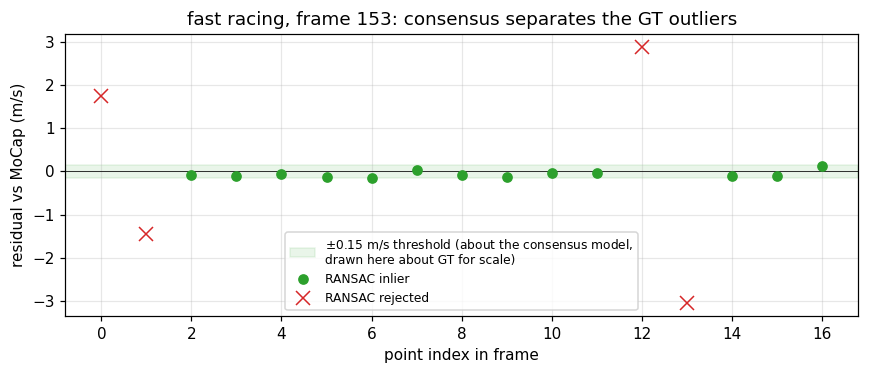

In [16]:
# 4c. The RANSAC prefilter (reve-style 3-point ego-velocity consensus) in action
# copied from validate_live_solver.py (the deployed default front end)
THRESH = 0.15   # solver.yaml radar_ransac_threshold
# IMPORTANT pipeline-order detail (verified in validate_live_solver.py): in
# deployment the prefilter runs on UNWRAPPED Doppler (pre-unwrap happens first).
# Running it on raw wrapped velocities makes the consensus lock onto alias
# populations on the aggressive bags. Here we mirror deployment by feeding the
# GT-unwrapped velocities.
def unwrapped_frame_velocities(d, i):
    v = np.asarray(d['radar'][i].velocities, float).copy()
    sel = d['fi'] == i
    v[d['pi'][sel]] = d['unw'][sel]
    return v

print(f"{'bag':<14} {'kept':>14}   {'med |r| kept':>13} {'med |r| rej':>12} "
      f"{'rej >3sig':>10}")
for key in BAG_KEYS:
    d = D[key]
    s3 = 3 * robust_sigma(d['r'])
    kept = tot = 0
    r_kept, r_rej = [], []
    for i, f in enumerate(d['radar']):
        if f.num_points() < 5:
            continue
        m = masks[key][i]
        kept += int(m.sum()); tot += len(m)
        sel = d['fi'] == i
        for rr, p in zip(d['r'][sel], d['pi'][sel]):
            if p < len(m):
                (r_kept if m[p] else r_rej).append(abs(rr))
    r_kept, r_rej = np.array(r_kept), np.array(r_rej)
    ratio = np.median(r_rej) / max(np.median(r_kept), 1e-9)
    print(f'{SHORT[key]:<14} {kept}/{tot} ({100*kept/tot:.0f}%)   '
          f'{np.median(r_kept):>11.3f}   {np.median(r_rej):>10.3f} ({ratio:.1f}x)  '
          f'{100*np.mean(r_rej > s3):>7.0f}%')
print('\nThe aggregate is the real validation: rejected points carry a several-fold')
print('higher median GT residual than kept points (strongest on racing; weaker on')
print('backflips, where the whole frame is noisy and sigma_rob is already 0.354 so')
print('fewer rejections clear the 3-sigma bar). A per-frame consensus can never')
print('match GT labels point-for-point: with 0.1-0.35 m/s noise against a 3-DoF')
print('model, borderline points fall on either side.')

# one illustrative fast-racing frame: pick the frame with the clearest
# kept/rejected separation in GT residuals (>=3 rejections)
d = D['fast_racing_best_velocity']
best, best_gap = None, -1
for i, m in masks['fast_racing_best_velocity'].items():
    sel = d['fi'] == i
    rr = d['r'][sel]; pp = d['pi'][sel]
    inl = np.array([m[p] for p in pp if p < len(m)])
    if inl.size < 8 or (~inl).sum() < 3:
        continue
    gap = np.median(np.abs(rr[~inl])) - np.median(np.abs(rr[inl]))
    if gap > best_gap:
        best, best_gap = i, gap
sel = d['fi'] == best
m = masks['fast_racing_best_velocity'][best]
rr = d['r'][sel]; pp = d['pi'][sel]
inl = np.array([m[p] if p < len(m) else True for p in pp])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axhline(0, color='k', lw=0.5)
ax.axhspan(-THRESH, THRESH, color='tab:green', alpha=0.10,
           label='$\\pm$0.15 m/s threshold (about the consensus model,\n'
                 'drawn here about GT for scale)')
ax.plot(np.where(inl)[0], rr[inl], 'o', color='tab:green', label='RANSAC inlier')
ax.plot(np.where(~inl)[0], rr[~inl], 'x', ms=9, color='tab:red',
        label='RANSAC rejected')
ax.set_xlabel('point index in frame')
ax.set_ylabel('residual vs MoCap (m/s)')
ax.set_title(f'fast racing, frame {best}: consensus separates the GT outliers')
ax.legend(fontsize=8)
fig.tight_layout()

The prefilter threshold is adopted from the reve baseline (Doer et al.): their
RANSAC accepts a point as an inlier when its Doppler residual against the 3-point
least-squares ego-velocity is below `inlier_thresh` = 0.15 m/s (their shipped
default; source vendored in `analysis/baselines/rio/reve/`). Our prefilter
reimplements exactly that test (fixed seed, 150 draws, a >=5-inlier acceptance
rule, run on unwrapped Doppler), so the number means the same thing in both
pipelines.

An adopted constant still has to hold on our own data, so the sweep below re-runs
the prefilter at thresholds 0.05-0.60 m/s and scores every kept/rejected split
against MoCap ground truth. The three panels: how many points survive (left); of
the rejected points, how many are truly bad, GT error > 3 sigma (middle); how many
truly bad points slip into the kept set (right). The dashed line is the deployed 0.15.

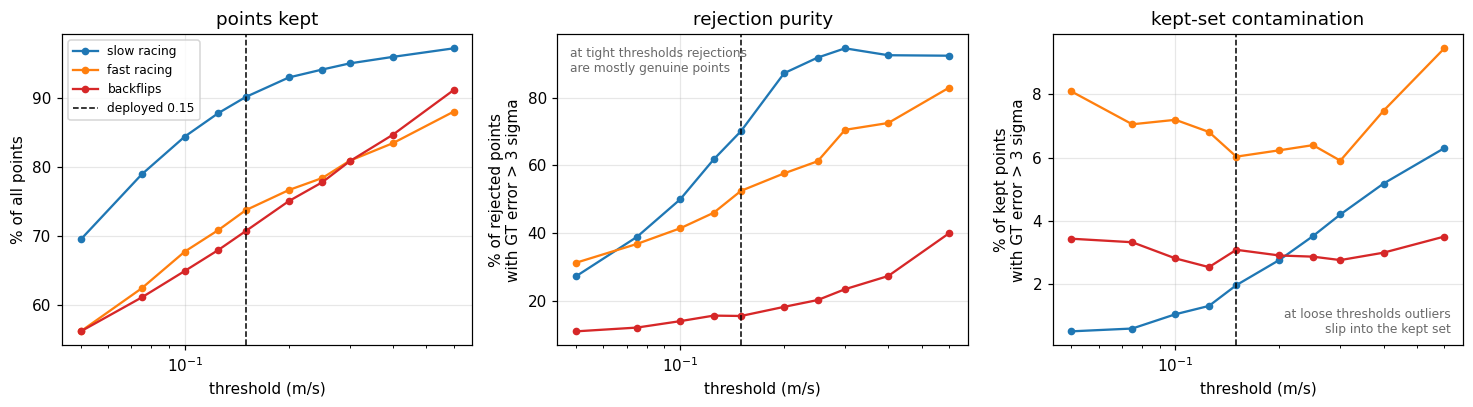

In [17]:
# 4d. The threshold: sweep the consensus inlier band and measure both failure
# edges against ground truth. The 150 sampled 3-point ego-velocity candidates per
# frame do not depend on the threshold, so each frame's candidate residual matrix
# is computed once and inliers are re-counted per threshold (identical to
# re-running the seeded RANSAC at every threshold).
SWEEP_T = np.array([0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25, 0.30, 0.40, 0.60])
sweep = {}
for key in BAG_KEYS:
    d = D[key]
    rng = np.random.default_rng(0)
    frames = []
    for i, f in enumerate(d['radar']):
        n = f.num_points()
        if n < 5:
            continue
        P = np.asarray(f.positions, float)
        v = np.asarray(f.velocities, float).copy()
        sel = d['fi'] == i
        v[d['pi'][sel]] = d['unw'][sel]          # deployment order: unwrap first
        Hn = P / np.maximum(np.linalg.norm(P, axis=1, keepdims=True), 1e-6)
        cand = []
        for _ in range(150):
            i3 = rng.choice(n, 3, replace=False)
            try:
                cand.append(np.linalg.solve(Hn[i3], v[i3]))
            except np.linalg.LinAlgError:
                continue
        if not cand:
            continue
        Rm = np.abs(Hn @ np.array(cand).T - v[:, None]).T
        r_gt = np.full(n, np.nan)
        r_gt[d['pi'][sel]] = np.abs(d['r'][sel])
        frames.append((Rm, r_gt))
    s3 = 3 * robust_sigma(d['r'])
    rows = []
    for T in SWEEP_T:
        kept = tot = n_byp = 0
        rk, rr, rk_cons = [], [], []
        for Rm, r_gt in frames:
            inl = Rm < T
            best = inl[np.argmax(inl.sum(axis=1))]
            bypassed = best.sum() < 5
            if bypassed:                          # deployed bypass: keep the frame
                best = np.ones(len(r_gt), bool)
                n_byp += 1
            kept += int(best.sum()); tot += len(best)
            ok = np.isfinite(r_gt)
            rk.extend(r_gt[best & ok]); rr.extend(r_gt[(~best) & ok])
            if not bypassed:
                rk_cons.extend(r_gt[best & ok])
        rk, rr, rk_cons = np.array(rk), np.array(rr), np.array(rk_cons)
        rows.append((100 * kept / tot,
                     100 * np.mean(rr > s3) if len(rr) else np.nan,
                     100 * np.mean(rk > s3) if len(rk) else np.nan,
                     100 * n_byp / len(frames),
                     100 * np.mean(rk_cons > s3) if len(rk_cons) else np.nan))
    sweep[key] = np.array(rows)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharex=True)
panels = [('points kept', '% of all points'),
          ('rejection purity', '% of rejected points\nwith GT error > 3 sigma'),
          ('kept-set contamination', '% of kept points\nwith GT error > 3 sigma')]
for col, (ax, (ti, yl)) in enumerate(zip(axes, panels)):
    for key in BAG_KEYS:
        ax.plot(SWEEP_T, sweep[key][:, col], '-o', ms=4, color=COLOR[key],
                label=SHORT[key])
    ax.axvline(0.15, color='k', lw=1, ls='--',
               label='deployed 0.15' if col == 0 else None)
    ax.set_xscale('log'); ax.set_xlabel('threshold (m/s)')
    ax.set_title(ti); ax.set_ylabel(yl)
axes[0].legend(fontsize=8)
axes[1].text(0.03, 0.96, 'at tight thresholds rejections\nare mostly genuine points',
             transform=axes[1].transAxes, va='top', fontsize=8, color='dimgray')
axes[2].text(0.97, 0.04, 'at loose thresholds outliers\nslip into the kept set',
             transform=axes[2].transAxes, ha='right', fontsize=8, color='dimgray')
fig.tight_layout()


> **What the sweep shows.** No metric is flat: tightening the threshold always
> rejects more points and loosening it always admits more, so the sweep cannot
> single out a value. What it does is bound the choice by two measured failure
> edges and show the deployed 0.15 breaks neither:
>
> - **Too tight (below ~0.1 m/s):** the consensus rejects mostly *genuine*
>   points (at 0.05 only 11-31% of rejections are true outliers), and more
>   frames fail to assemble 5 inliers and bypass the filter whole (fast: 12.7%
>   of frames at 0.05 vs 6.3% at 0.15; bypassed frames carry 26-41% outliers).
>   Net effect: fast contamination *rises* as the threshold tightens.
> - **Too loose (above ~0.2 m/s):** outliers are admitted (slow contamination
>   2.0% at 0.15 rising to 4.2% at 0.30) and only the egregious ones are still
>   rejected.
>
> Between those edges every value trades points kept against contamination with
> no clearly better choice on any bag. The deployed 0.15 (about 1.5x the
> quiet-regime noise floor, $\sigma_{rob}$ slow = 0.097 m/s) is a fair
> trade-off that breaks nothing, so the stock value adopted from reve stands.
>
> One thing no threshold fixes: consensus-passing fast frames hold a
> near-constant 4.5-5.7% contamination across T = 0.05-0.30. That is the
> unflaggable remainder of chapter 3, and the Huber kernel's remit.


> **Design consequence.**
>
> *4a, the error is regime-structured:* steep rays are noisier on both regimes and
> gain a +0.7 m/s bias only under sustained flips. So steep rays stay in (they are
> the sole carriers of vertical velocity), elevation is never hard-gated, and the
> flip regime is treated as its own problem.
>
> *4b, strong returns are quieter:* sigma falls toward the strong-intensity end on
> every bag, so each point is weighted by its intensity relative to the frame
> median (the inverse-variance choice), applied unclamped: the measured per-point
> relative intensities stay within 0.39-3.3, so the former [0.25, 4] guardrail
> never engaged and was deleted from the solver.
>
> *4c/4d, frames overdetermine the ego-velocity:* 10-13 returns for 3 unknowns, so
> a per-frame consensus drops the minority that disagree, whatever the cause;
> rejected points carry 2-8x the ground-truth residual of kept ones. The threshold
> sweep bounds the choice by two measured failure edges (rejecting genuine
> points below ~0.1 m/s, admitting outliers above ~0.2) with no clearly better
> value between them; the deployed 0.15 (reve's stock value, same residual
> definition) breaks neither edge, so it stays unchanged.
>
> A ~5% hard core of wrong-but-consensus-passing points survives any threshold:
> that remainder is what the Huber kernel is for (chapter 3). What each layer is
> worth end to end is measured in chapter 9's ablation ledger.

## 5. The adaptive weighting curve (the centerpiece)

How much should each sensor be trusted *as a function of flight dynamics*? This chapter
walks analysis $\to$ discovery $\to$ mechanism five times, and every weight in the
deployed solver falls out of one of the five:

1. **5a, detect:** how does each sensor's residual grow with body rate $|\omega|$?
   (radar and accel degrade sharply, the gyro barely)
2. **5b, isolate and fit:** split the radar noise into a per-point and a frame-shared
   component, test a physical noise model on the clean part, and measure the model's
   one parameter $\omega_0$. The measured value is what the solver deploys
   (`omega_soft_sigma`).
3. **5c, two traps:** why the naive $\lambda = 1/\sigma^2$ read off these curves fails
   (intra-frame correlation; out-of-band noise).
4. **5d, model the correlation exactly:** the $\sigma_c$ whitening (deployed default).
5. **5e, derive the statics:** $\lambda^\ast = 1/(\sigma^2 f_s \tau_{corr})$ from
   measured inputs; the deployed static weights are these numbers, unedited.


The middle-panel radar blow-up starts exactly at v_max: past it returns alias,
and the aliased population carries the broken-bearing error floor (ch. 6b) --
a speed-gated mechanism, not smear. Below v_max the rise is the gentle part.
CAUTION reading these panels side by side: |omega| and |v| are correlated on
these flights (aggressive segments are fast AND rotating, spearman ~ +0.5),
and low sin(theta) means the ray is aligned with the velocity, i.e. |Doppler|
near its maximum, where aliasing lives. No single panel attributes cause;
5b isolates the clean statistic.


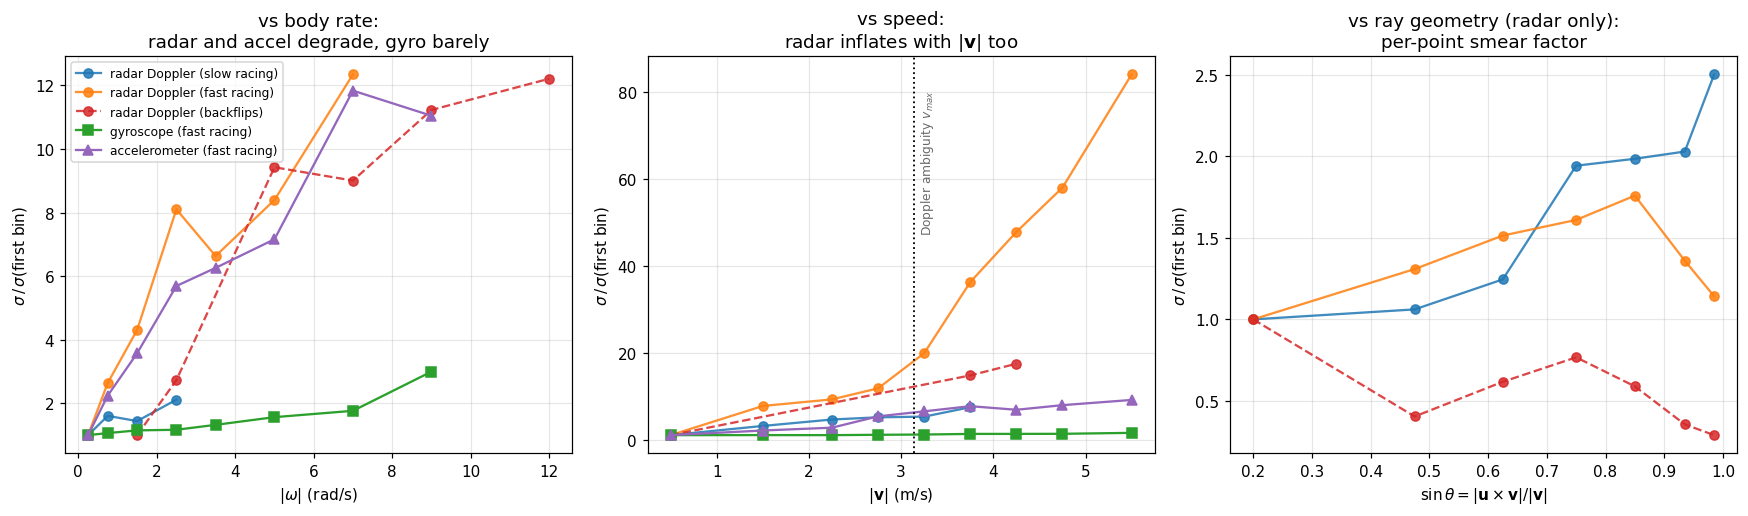

In [18]:
# 5a. Noise inflation vs body rate, speed, and ray geometry (the raw detection)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
d = D['fast_racing_best_velocity']

V_BIN_EDGES = np.array([0, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0])
SIN_BIN_EDGES = np.array([0, 0.4, 0.55, 0.7, 0.8, 0.9, 0.97, 1.0001])

def speed_at(dd, t):
    vi = interp1d(dd['st_t'], np.array([s.velocity for s in dd['states']]),
                  axis=0, kind='linear', bounds_error=False,
                  fill_value='extrapolate')
    return np.linalg.norm(vi(t), axis=1)

def sin_theta(dd, v_pts):
    # per-point ray-vs-velocity angle from the model itself: pred_j = -u_j . v
    cosb = np.clip(dd['pred'] / np.maximum(v_pts, 0.2), -1, 1)
    return np.sqrt(1 - cosb**2)

# radar: per-point residual sigma binned by |omega|, |v|, sin(theta),
# all three bags (global bag colors; backflips dashed)
for key in BAG_KEYS:
    dd = D[key]
    style = dict(ls='--' if 'backflips' in key else '-', color=COLOR[key],
                 alpha=0.85, label=f'radar Doppler ({SHORT[key]})')
    t_pts = np.array([dd['radar'][i].timestamp for i in dd['fi']]) + RADAR_OFF
    v_pts = speed_at(dd, t_pts)
    for ax, xv, edges in [(axes[0], dd['om_pts'], OMEGA_BIN_EDGES),
                          (axes[1], v_pts, V_BIN_EDGES),
                          (axes[2], sin_theta(dd, v_pts), SIN_BIN_EDGES)]:
        c_r, s_r, _ = binned_sigma(xv, dd['r'], edges)
        ax.plot(c_r, s_r / s_r[0], marker='o', **style)

# gyro and accel residuals vs the MoCap reference, binned by |omega| and |v|
# (sin(theta) is a radar ray-geometry factor; it does not exist for the IMU)
t_imu = np.array([m.timestamp for m in d['imu']]) + IMU_OFF
om_ref = d['om_interp'](t_imu)
om_imu = np.linalg.norm(om_ref, axis=1)
v_imu = speed_at(d, t_imu)
g_res = np.array([m.angular_velocity for m in d['imu']]) - om_ref
g_res -= np.median(g_res, axis=0)
for ax, xv, edges in [(axes[0], om_imu, OMEGA_BIN_EDGES),
                      (axes[1], v_imu, V_BIN_EDGES)]:
    c_g, s_g, _ = binned_sigma(np.repeat(xv, 3), g_res.ravel(), edges)
    ax.plot(c_g, s_g / s_g[0], '-s', color='tab:green',
            label='gyroscope (fast racing)')

if d['states'][0].acceleration is not None:
    ac_i = interp1d(d['st_t'], np.array([s.acceleration for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False,
                    fill_value='extrapolate')
    qu_i = interp1d(d['st_t'], np.array([s.orientation for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False,
                    fill_value='extrapolate')
    G = np.array([0.0, 0.0, -9.81])
    acc = np.array([m.linear_acceleration for m in d['imu']])
    a_w = ac_i(t_imu); q_all = qu_i(t_imu)
    a_res = np.empty_like(acc)
    for i in range(len(t_imu)):
        a_res[i] = acc[i] - quat_to_rotation_matrix(q_all[i]).T @ (a_w[i] - G)
    a_res -= np.median(a_res, axis=0)
    for ax, xv, edges in [(axes[0], om_imu, OMEGA_BIN_EDGES),
                          (axes[1], v_imu, V_BIN_EDGES)]:
        c_a, s_a, _ = binned_sigma(np.repeat(xv, 3), a_res.ravel(), edges)
        ax.plot(c_a, s_a / s_a[0], '-^', color='tab:purple',
                label='accelerometer (fast racing)')

axes[0].set_xlabel('$|\\omega|$ (rad/s)')
for ax in axes:
    ax.set_ylabel('$\\sigma\\,/\\,\\sigma$(first bin)')
axes[0].set_title('vs body rate:\nradar and accel degrade, gyro barely')
axes[1].axvline(d['v_max'], color='k', ls=':', lw=1.2)
axes[1].text(d['v_max'] + 0.06, 0.55, 'Doppler ambiguity $v_{max}$',
             transform=axes[1].get_xaxis_transform(), rotation=90,
             fontsize=8, color='dimgray', va='bottom')
axes[1].set_xlabel('$|\\mathbf{v}|$ (m/s)')
axes[1].set_title('vs speed:\nradar inflates with $|\\mathbf{v}|$ too')
axes[2].set_xlabel('$\\sin\\theta = |\\mathbf{u}\\times\\mathbf{v}|/|\\mathbf{v}|$')
axes[2].set_title('vs ray geometry (radar only):\nper-point smear factor')
axes[0].legend(fontsize=8)
fig.tight_layout()
print('The middle-panel radar blow-up starts exactly at v_max: past it returns alias,')
print('and the aliased population carries the broken-bearing error floor (ch. 6b) --')
print('a speed-gated mechanism, not smear. Below v_max the rise is the gentle part.')
print('CAUTION reading these panels side by side: |omega| and |v| are correlated on')
print('these flights (aggressive segments are fast AND rotating, spearman ~ +0.5),')
print('and low sin(theta) means the ray is aligned with the velocity, i.e. |Doppler|')
print('near its maximum, where aliasing lives. No single panel attributes cause;')
print('5b isolates the clean statistic.')


**Finding (5a).** Radar and accelerometer residual $\sigma$ inflate 7-12x between
hover and ~7 rad/s; the gyroscope stays within ~3x of its low-rate floor. That
ordering is the detection: the two streams whose errors are dominated by geometry and
vibration must lose weight as the platform spins; the gyro must not.

**Why these curves cannot calibrate a law.** They are total residuals against the
MoCap reference, and the reference error itself (timestamp jitter, interpolation)
grows with motion, so each curve is an upper bound on the sensor's own degradation.
Testing a physical error-budget hypothesis needs the statistic reference error
cannot touch: the within-frame component $\sigma_i$. The next cell defines that
decomposition and the hypothesis; 5b then measures both.


**The noise decomposition used from 5b on (defined here).** Every kept return $j$ in
radar frame $f$ carries a Doppler residual modeled as

$$ r_{fj} = c_f + e_{fj}, \qquad c_f \sim (0,\, \sigma_c^2), \qquad
   e_{fj} \sim (0,\, \sigma_i^2) $$

$c_f$ is the **frame-shared** error: whatever the whole frame gets wrong together
(reference velocity error at that instant, timestamp error, scene-wide multipath).
$e_{fj}$ is the **per-point** error, independent from return to return (thermal noise,
quantization, per-ray geometry). Both scales are estimated per bag from two
complementary statistics:

- *Within* one frame, deviations from the frame's own mean cancel $c_f$ exactly, so
  the average within-frame variance estimates $\sigma_i^2$ with no contribution from
  the frame-shared error.
- *Across* frames, the frame means $\bar r_f$ scatter for two reasons: their shared
  errors $c_f$ (variance $\sigma_c^2$), and the per-point noise that a finite average
  over $N_f$ returns has not removed (variance $\sigma_i^2/N_f$). With $\bar N$ the
  average number of kept returns per frame,

$$ \operatorname{Var}_f(\bar r_f) \;\approx\; \sigma_c^2 + \frac{\sigma_i^2}{\bar N}
   \qquad\Rightarrow\qquad
   \hat\sigma_c^2 \;=\; \operatorname{Var}_f(\bar r_f) - \frac{\hat\sigma_i^2}{\bar N} $$

<details>
<summary><b>Unfold: the cancellation in two lines</b></summary>

> **The cancellation, step by step.**
>
> With $r_{fj} = c_f + e_{fj}$ and the frame's own mean $\bar r_f = c_f + \bar e_f$ (the constant $c_f$ passes through the average), each point's deviation from its frame mean is
>
> $$ r_{fj} - \bar r_f \;=\; (c_f + e_{fj}) - (c_f + \bar e_f) \;=\; e_{fj} - \bar e_f $$
>
> The $c_f$ terms subtract out exactly, for any $N_f$: the cancellation is algebraic, because $c_f$ is the same number for every return in the frame. Across frames the mean $\bar r_f$ still contains $\bar e_f$, the average of $N_f$ independent per-point errors; averaging only shrinks its variance,
>
> $$ \operatorname{Var}(\bar r_f) \;=\; \operatorname{Var}(c_f) + \operatorname{Var}(\bar e_f) \;=\; \sigma_c^2 + \sigma_i^2/N_f, $$
>
> and only $N_f \to \infty$ would remove the second term. So: exact cancellation within the frame (constant across the group), $1/N$ attenuation across frames (independent across the group). At $\bar N \approx 10$-$13$ the surviving $\sigma_i^2/\bar N$ is comparable to $\sigma_c^2$ itself, hence the subtraction below.
>
> *Notation bridge to the estimator above:* $\operatorname{Var}$ with no subscript is the theoretical variance of one frame's mean under the noise model, stated with the true parameters $\sigma_i^2, \sigma_c^2$ (no hats) and that frame's own $N_f$ (kept returns in frame $f$). The estimator replaces each piece by its measurable counterpart: $\operatorname{Var}_f$ is the empirical scatter of the observed $\bar r_f$ across frames (which averages the per-frame variances, turning $\sigma_i^2/N_f$ into $\sigma_i^2/\bar N$), and hats ($\hat\sigma_i^2, \hat\sigma_c^2$) mark measured plug-in estimates of those true parameters.

</details>

The sum is the crucial part: frame means would scatter even if radar errors
were purely per-point ($\sigma_c = 0$), by exactly $\sigma_i^2/\bar N$; only the
excess above that baseline is evidence of a shared component. It also makes
$\hat\sigma_c^2$ a noisy estimator (a difference of two similar numbers, clamped at
zero), which is why 5b's right panel needs $\geq 8$ frames per bin and still
scatters.

The split matters because $\sigma_i$ is *immune to reference error*: anything shared
by the whole frame, including any error of the MoCap reference itself, cancels inside
within-frame deviations. So $\sigma_i(|\omega|)$ is the honest place to test a sensor
noise model, while the total curves in 5a are only upper bounds.

**The physical hypothesis 5b will test (an error budget, not a fitted curve shape):**
radar error should have a rate-independent floor $\sigma_0$ (thermal noise,
quantization, static multipath) plus an intra-frame motion-smearing term, and the
smearing term should be *linear* in $|\omega|$. The linearity is not an assumption,
it follows from the forward model. A static scatterer seen along the body-frame unit
ray $\mathbf{u}(t)$ from a platform with velocity $\mathbf{v}$ returns the radial
velocity

$$ v_r(t) = -\,\mathbf{u}(t)^\top \mathbf{v}. $$

While the platform rotates with body rate $\boldsymbol\omega$, the ray to a fixed
scatterer rotates in the body frame as $\dot{\mathbf{u}} = -\boldsymbol\omega \times
\mathbf{u}$, so

$$ \frac{d v_r}{dt} = -\dot{\mathbf{u}}^\top \mathbf{v}
   = (\boldsymbol\omega \times \mathbf{u})^\top \mathbf{v}
   = \boldsymbol\omega^\top (\mathbf{u} \times \mathbf{v}) $$

Taking magnitudes, first Cauchy-Schwarz on the dot product, then
$|\mathbf{u}\times\mathbf{v}| = |\mathbf{u}|\,|\mathbf{v}|\sin\theta$ with
$|\mathbf{u}| = 1$ and $\theta$ the angle between the ray and the velocity:

$$ \left|\frac{d v_r}{dt}\right|
   \;\le\; |\boldsymbol\omega|\,|\mathbf{u}\times\mathbf{v}|
   \;=\; |\boldsymbol\omega|\,|\mathbf{v}|\,
   \underbrace{\frac{|\mathbf{u}\times\mathbf{v}|}{|\mathbf{v}|}}_{\sin\theta\,\in\,[0,1]}
   \;\le\; |\boldsymbol\omega|\,|\mathbf{v}|. $$

A radar frame is not an instantaneous sample: the chip integrates over the frame's
processing interval $T_\mathrm{frame}$ (tens of ms). Over that interval the return
along ray $\mathbf{u}_j$ therefore drifts by up to
$|\omega|\,|\mathbf{v}|\,T_\mathrm{frame}\,\sin\theta_j$: every return's smear
grows linearly in $|\omega|$, scaled per return by its own geometry factor
$\sin\theta_j = |\mathbf{u}_j\times\mathbf{v}|/|\mathbf{v}|$ (zero for a ray along
the velocity, one perpendicular to it), with the worst case $\sin\theta_j = 1$
recovering the frame-wide bound $|\omega|\,|\mathbf{v}|\,T_\mathrm{frame}$.

What that drift does to the *measured* Doppler: the chip does not report
$v_r(t)$ as a function, it reports one number per return, obtained from an FFT
over the chirps of the interval. When $v_r$ drifts by $\Delta_j$ during the
interval, the return's energy smears across $\sim\Delta_j$ worth of Doppler
bins, and the single reported number lands somewhere inside that smeared band.
Our residual compares that number against the model's instantaneous $v_r$ at
the frame timestamp, so the drift *bounds* the resulting per-return error; it
is not the error itself. Where inside the band the reported value lands varies
with scene and processing, so over many returns the effect is a zero-mean
scatter whose width scales with the drift. Writing the realized error as
$e_j = \kappa_j\,\Delta_j$ with a scene-dependent factor
$\kappa_j \in [-1, 1]$, the standard deviation over returns compresses the
bound into a noise term linear in $|\omega|$:

$$ \sigma_\mathrm{smear} \;=\; \sqrt{\mathbb{E}\bigl[e_j^2\bigr]}
   \;=\; \underbrace{\sqrt{\mathbb{E}\bigl[\kappa_j^2 \sin^2\theta_j\bigr]}\;
   |\mathbf{v}|\; T_\mathrm{frame}}_{\text{lumped into } \sigma_0/\omega_0}
   \;\cdot\; |\omega|
   \;\;\equiv\;\; \sigma_0\, \frac{|\omega|}{\omega_0} $$

$T_\mathrm{frame}$, typical speed, and the spread of the per-ray factors
$\sin\theta_j$ are thus absorbed into the single measurable constant
$\omega_0$: the body rate at which smearing equals the floor. Floor and smear come from independent
physical sources, so they add in quadrature:

$$ \sigma^2(|\omega|) = \sigma_0^2 + \left(\sigma_0 \frac{|\omega|}{\omega_0}\right)^2
   \;\;\Rightarrow\;\; \sigma(|\omega|) = \sigma_0 \sqrt{1 + (|\omega|/\omega_0)^2},
   \qquad w = \frac{\sigma_0^2}{\sigma^2} = \frac{1}{1 + (|\omega|/\omega_0)^2} $$

$\omega_0$, the body rate at which smearing equals the floor, is the model's one free
parameter. It is not guessed and not tuned: 5b measures it, and the measured value is
deployed.


omega_0 (joint racing) = 4.52 +- 0.53 rad/s   (fast alone 4.63 +- 0.48; rel. fit residual 8.1%)
ratio slope vs |omega| (68% CI, per rad/s):  slow racing [-0.133, +0.168];  fast racing [-0.054, +0.021];  backflips [+0.021, +0.057]
whole-flight aggregates sigma_c/sigma_i:  slow racing 0.53,  fast racing 0.30,  backflips 0.26


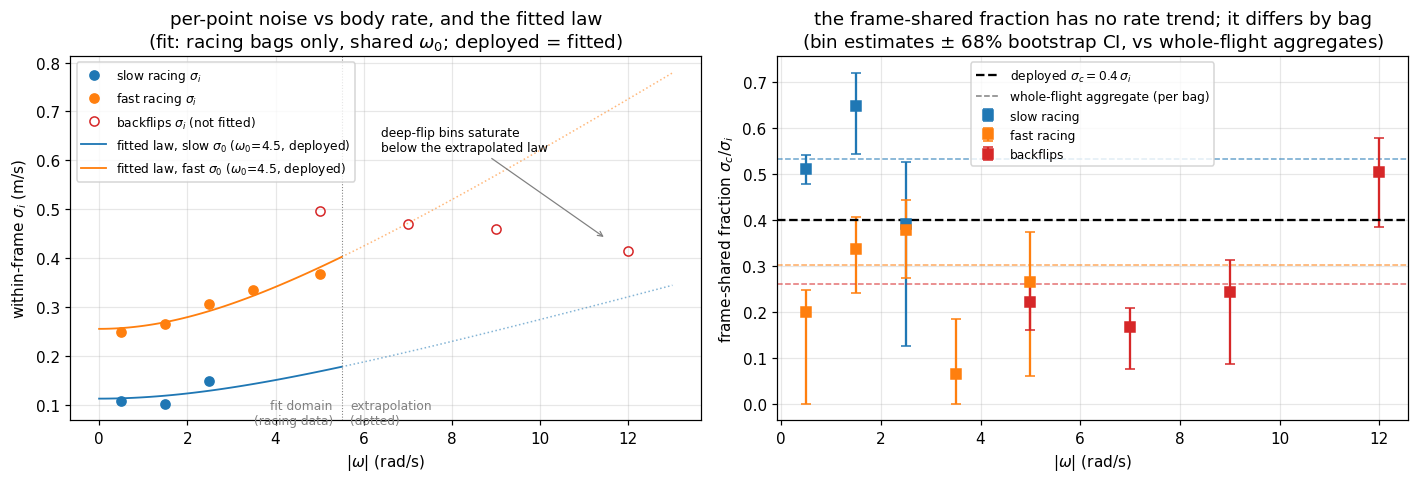

In [19]:
# 5b. Isolate the per-point noise and fit the law. Using the decomposition
#     defined above: within-frame sigma_i (per-point, immune to frame-shared
#     reference error) vs frame-shared sigma_c. Fit
#     sigma_i(|omega|) = sigma_0*sqrt(1+(|omega|/omega_0)^2) on the racing bags;
#     backflips is displayed but NOT fitted (deep-flip frames are dominated by
#     the aliased-bearing mechanism of ch. 6b, not by motion smear).
#     Adapted from analysis/characterize_sigma_c_vs_omega.py.
EDGES = [0, 1, 2, 3, 4, 6, 8, 10, 14]
OM0_DEPLOYED = 4.5   # deployed = the fitted value (adopted 2026-07-27; replaces
                     # the earlier hand-set 4.0, the last underived number in
                     # the radar weighting -- see FEEDBACK_PLAN)

def frame_components(key):
    '''per-frame (within-var, mean, n, |omega|) for frames with >=6 kept points'''
    d = D[key]
    r, fi = d['r'], d['fi']
    s_all = robust_sigma(r)
    keep = np.abs(r - np.median(r)) < 6 * s_all
    out = []
    for f in np.unique(fi):
        m = (fi == f) & keep
        if np.sum(m) >= 6:
            om = np.linalg.norm(d['om_interp'](d['radar'][int(f)].timestamp
                                               + RADAR_OFF))
            out.append((np.var(r[m], ddof=1), np.mean(r[m]), int(np.sum(m)), om))
    return out

def bin_comps(sel):
    '''(sigma_i, sigma_c) from an (N,4) array of per-frame components'''
    s_i2 = sel[:, 0].mean()
    s_c2 = max(np.var(sel[:, 1], ddof=1) - s_i2 / sel[:, 2].mean(), 0.0)
    return np.sqrt(s_i2), np.sqrt(s_c2)

def binned_components(frames, n_boot=400, seed=0):
    '''sigma_i / sigma_c per omega bin, with bootstrap-over-frames 68% CIs.
    Bins need >=8 frames (each with >=6 kept points), which is why the curves
    carry few markers: sigma_c is a variance DIFFERENCE and needs many frames
    per bin before it means anything.'''
    rng = np.random.default_rng(seed)
    rows = []
    for lo, hi in zip(EDGES[:-1], EDGES[1:]):
        sel = np.array([v for v in frames if lo <= v[3] < hi])
        if len(sel) < 8:
            continue
        s_i, s_c = bin_comps(sel)
        boots = np.array([bin_comps(sel[rng.integers(0, len(sel), len(sel))])
                          for _ in range(n_boot)])
        ratio_b = boots[:, 1] / np.maximum(boots[:, 0], 1e-9)
        rows.append(dict(om=0.5 * (lo + hi), s_i=float(s_i), s_c=float(s_c),
                         ratio=float(s_c / max(s_i, 1e-9)),
                         ci_ratio=np.percentile(ratio_b, [16, 84]), n=len(sel)))
    return rows

FRAMES = {key: frame_components(key) for key in BAG_KEYS}
comp = {key: binned_components(FRAMES[key]) for key in BAG_KEYS}

# ---- the fit: joint over BOTH racing bags (shared omega_0, per-bag sigma_0).
# Protocol pinned in the paper record (FEEDBACK_PLAN 2026-07-16): bin centers,
# unweighted least squares on the binned sigma_i.
racing = ['slow_racing_best_velocity', 'fast_racing_best_velocity']
om_all = np.array([b['om'] for k in racing for b in comp[k]])
si_all = np.array([b['s_i'] for k in racing for b in comp[k]])
is_fast = np.array([float(k == 'fast_racing_best_velocity')
                    for k in racing for b in comp[k]])

def law_joint(X, s0_slow, s0_fast, om0):
    om, isf = X
    s0 = s0_slow * (1 - isf) + s0_fast * isf
    return s0 * np.sqrt(1 + (om / om0) ** 2)

p, cov = curve_fit(law_joint, (om_all, is_fast), si_all, p0=[0.08, 0.12, 4.0])
om0_joint, om0_err = p[2], np.sqrt(cov[2, 2])
pf, covf = curve_fit(lambda om, s0, om0: s0 * np.sqrt(1 + (om / om0) ** 2),
                     om_all[is_fast > 0.5], si_all[is_fast > 0.5], p0=[0.12, 4.0])
rel_res = np.sqrt(np.mean(((law_joint((om_all, is_fast), *p) - si_all)
                           / si_all) ** 2))

# ---- right-panel support: whole-flight aggregate ratio per bag + a rate-trend
# test (bootstrap-over-frames OLS slope of the binned ratio vs |omega|).
agg_ratio = {}
for k in BAG_KEYS:
    s_i, s_c = bin_comps(np.array(FRAMES[k]))
    agg_ratio[k] = s_c / max(s_i, 1e-9)

def ratio_slope_ci(key, n_boot=400, seed=1):
    frames, rng = FRAMES[key], np.random.default_rng(seed)
    slopes = []
    for _ in range(n_boot):
        bs = [frames[j] for j in rng.integers(0, len(frames), len(frames))]
        pts = np.array([(r['om'], r['ratio'])
                        for r in binned_components(bs, n_boot=1)])
        if len(pts) >= 2:
            slopes.append(np.polyfit(pts[:, 0], pts[:, 1], 1)[0])
    return np.percentile(slopes, [16, 84])

sl = {k: ratio_slope_ci(k) for k in BAG_KEYS}

# ---- figure ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
om_fit_max = float(om_all.max()) + 0.5          # end of racing data support
xf = np.linspace(0, om_fit_max, 120)
xe = np.linspace(om_fit_max, 13, 120)
for key in BAG_KEYS:
    rows, fitted = comp[key], key in racing
    axes[0].plot([b['om'] for b in rows], [b['s_i'] for b in rows], 'o',
                 color=COLOR[key], mfc=COLOR[key] if fitted else 'none',
                 label=f"{SHORT[key]} $\\sigma_i$"
                       + ('' if fitted else ' (not fitted)'))
for s0, col, name in [(p[0], 'tab:blue', 'slow'), (p[1], 'tab:orange', 'fast')]:
    axes[0].plot(xf, s0 * np.sqrt(1 + (xf / om0_joint) ** 2), '-', color=col,
                 lw=1.2, label=f'fitted law, {name} $\\sigma_0$ '
                               f'($\\omega_0$={om0_joint:.1f}, deployed)')
    axes[0].plot(xe, s0 * np.sqrt(1 + (xe / om0_joint) ** 2), ':', color=col,
                 lw=1, alpha=0.55)
axes[0].axvline(om_fit_max, color='gray', lw=0.7, ls=':')
axes[0].text(om_fit_max - 0.2, 0.055, 'fit domain\n(racing data)', ha='right',
             va='bottom', fontsize=8, color='gray')
axes[0].text(om_fit_max + 0.2, 0.055, 'extrapolation\n(dotted)', ha='left',
             va='bottom', fontsize=8, color='gray')
axes[0].annotate('deep-flip bins saturate\nbelow the extrapolated law',
                 xy=(11.5, 0.44), xytext=(6.4, 0.62), fontsize=8,
                 arrowprops=dict(arrowstyle='->', lw=0.8, color='gray'))
axes[0].set_xlabel('$|\\omega|$ (rad/s)')
axes[0].set_ylabel('within-frame $\\sigma_i$ (m/s)')
axes[0].set_title('per-point noise vs body rate, and the fitted law\n'
                  '(fit: racing bags only, shared $\\omega_0$; deployed = fitted)')
axes[0].legend(fontsize=8, loc='upper left')
for key in BAG_KEYS:
    rows = comp[key]
    yerr = np.abs(np.array([b['ci_ratio'] for b in rows]).T
                  - np.array([b['ratio'] for b in rows]))
    axes[1].errorbar([b['om'] for b in rows], [b['ratio'] for b in rows],
                     yerr=yerr, fmt='s', capsize=3, color=COLOR[key],
                     label=SHORT[key])
    axes[1].axhline(agg_ratio[key], color=COLOR[key], ls='--', lw=1, alpha=0.65)
axes[1].axhline(0.4, color='k', ls='--', lw=1.5,
                label='deployed $\\sigma_c = 0.4\\,\\sigma_i$')
axes[1].plot([], [], '--', color='gray', lw=1,
             label='whole-flight aggregate (per bag)')
axes[1].set_xlabel('$|\\omega|$ (rad/s)')
axes[1].set_ylabel('frame-shared fraction $\\sigma_c / \\sigma_i$')
axes[1].set_title('the frame-shared fraction has no rate trend; it differs by bag\n'
                  '(bin estimates $\\pm$ 68% bootstrap CI, vs whole-flight aggregates)')
axes[1].legend(fontsize=8, loc='upper center')
fig.tight_layout()

# ---- computed numbers the markdown below refers to ----
print(f'omega_0 (joint racing) = {om0_joint:.2f} +- {om0_err:.2f} rad/s   '
      f'(fast alone {pf[1]:.2f} +- {np.sqrt(covf[1,1]):.2f}; '
      f'rel. fit residual {100*rel_res:.1f}%)')
print('ratio slope vs |omega| (68% CI, per rad/s):  '
      + ';  '.join(f'{SHORT[k]} [{sl[k][0]:+.3f}, {sl[k][1]:+.3f}]'
                   for k in BAG_KEYS))
print('whole-flight aggregates sigma_c/sigma_i:  '
      + ',  '.join(f'{SHORT[k]} {agg_ratio[k]:.2f}' for k in BAG_KEYS))


**How the numbers above are computed.** Per frame $f$ with $N_f$ kept returns
($N_f \ge 6$, residuals outside $6\sigma$ of the bag median dropped first):

$$ \bar r_f = \frac{1}{N_f}\sum_j r_{fj}, \qquad
   s_f^2 = \frac{1}{N_f-1}\sum_j (r_{fj}-\bar r_f)^2,
   \qquad \mathbb{E}[s_f^2] = \sigma_i^2 $$

($c_f$ drops out of $s_f^2$, which is what makes it reference-immune). Frames are
binned by $|\omega|$; each bin $B$ (at least 8 frames) yields

$$ \hat\sigma_i^2(B) = \operatorname{mean}_{f\in B} s_f^2, \qquad
   \hat\sigma_c^2(B) = \max\Bigl(\operatorname{Var}_{f\in B}(\bar r_f)
   - \hat\sigma_i^2(B)/\bar N_B,\; 0\Bigr) $$

(the decomposition cell's identity, applied per bin). The law is then fitted by least squares
over the racing bins jointly, with one shared $\omega_0$ but a per-bag floor:

$$ \min_{\sigma_0^{\mathrm{slow}},\,\sigma_0^{\mathrm{fast}},\,\omega_0}
   \sum_{B}\Bigl[\hat\sigma_i(B) - \sigma_0^{\mathrm{bag}(B)}
   \sqrt{1+(\omega_B/\omega_0)^2}\Bigr]^2 $$

The floor $\sigma_0$ is scene- and range-dependent (hence per bag: 0.11 vs 0.26
m/s), while the hypothesis says the *rate response* is platform physics, hence
shared. The quoted $\pm$ is the 1$\sigma$ parameter uncertainty from the fit
Jacobian; the protocol spread comes from re-running the fit under equally
defensible protocol choices (frame-count-weighted bins, per-bin mean $|\omega|$
instead of centers). The 68% CIs and the slope test are bootstrap-over-frames:
resample frames with replacement, rebuild the bins, recompute the ratio (and, for
the slope, an OLS line of ratio vs bin center), take the 16/84 percentiles.

**From noise law to weight law.** Inverse-variance weighting, normalized so a
low-rate measurement has weight 1:

$$ w(|\omega|) = \frac{\sigma_0^2}{\sigma^2(|\omega|)}
   = \frac{1}{1+(|\omega|/\omega_0)^2} $$

In the solver this multiplies each radar factor's information at problem-build time
(equivalently: inflates that frame's $\sigma$ by $1/\sqrt{w}$), with $|\omega|$
taken from the warm-start spline. Continuous down-weighting, no hard gate.

**Finding (left panel).** The error-budget law fits the reference-immune per-point
noise across the racing envelope: $\omega_0 = 4.5 \pm 0.5$ rad/s (joint racing; fast
alone $4.6 \pm 0.5$). Protocol spread (honesty check): frame-count weighting or
per-bin mean $|\omega|$ move the estimate to $\sim 3.9 \pm 0.4$. The data pins
$\omega_0$ to 4-5, not to a point.

**Consequence.** The solver deploys the fitted value:
$w = 1/(1+(|\omega|/4.5)^2)$ (`omega_soft_sigma=4.5`, adopted 2026-07-27, replacing
a hand-set 4.0, the last underived number in the radar weighting). Metrics are flat
across the measured band, so the residual choice inside it is uncritical (ch. 9
ledger). Beyond the racing envelope the backflip bins saturate *below* the
extrapolated law: there the law down-weights radar more than measured $\sigma_i$
alone would ask. That bias is conservative in exactly the regime where bearings are
least trustworthy (ch. 6b); backflips remains a declared limit.

**Finding (right panel).** The frame-shared fraction $\sigma_c/\sigma_i$ obeys no
rate law: 2 of 3 slope CIs straddle zero and the slope signs disagree across bags
(printed above), while the whole-flight aggregates differ by 2x across bags
(0.53 / 0.30 / 0.26). The correlated fraction is a per-platform/scene property, not
a dynamics property. The per-bin scatter (0.07-0.65) is wider than the CIs suggest:
$\sigma_c^2$ is a variance difference (the noisiest estimator in this notebook, see
the decomposition cell), and the CIs only resample frames within a bin, so scene changes between
bins are not captured by them.

**Consequence.** Model the frame-shared error as rate-independent, one number for
the platform: $\sigma_c = 0.4\,\sigma_i$, the midpoint of the per-bag aggregates.
5d builds the whitening that consumes it; end-to-end evidence in the ch. 9 ledger.


In [20]:
# 5c. Two traps between the measured curves and usable weights. The obvious
#     move is lambda = 1/sigma^2 with sigma read straight off 5a/5b. It fails
#     for two measured reasons, quantified here:
#     (i) returns within a frame are correlated (sigma_c > 0) -> a frame
#         carries far fewer independent measurements than points,
#     (ii) most IMU residual power lies above the spline band -> the raw sigma
#         overstates the noise the spline actually has to absorb.
#     Adapted from analysis/characterize_frame_correlation.py.
print(f"{'bag':<14} {'sigma_i':>8} {'sigma_c':>8} {'rho':>6} {'N':>5} {'N_eff':>6}   "
      f"{'gyro raw':>9} {'in-band':>8}")
for key in BAG_KEYS:
    d = D[key]
    frames = frame_components(key)
    wi = np.array([v[0] for v in frames]); mu = np.array([v[1] for v in frames])
    ns = np.array([v[2] for v in frames])
    s_i2 = np.mean(wi)
    s_c2 = max(np.var(mu, ddof=1) - s_i2 / np.mean(ns), 0.0)
    rho = s_c2 / (s_c2 + s_i2)
    N = np.mean(ns)
    n_eff = N / (1 + (N - 1) * rho)   # Kish design effect
    # in-band (10 Hz low-pass) gyro residual vs raw
    t_imu = np.array([m.timestamp for m in d['imu']]) + IMU_OFF
    g_res = np.array([m.angular_velocity for m in d['imu']]) - d['om_interp'](t_imu)
    g_res -= np.median(g_res, axis=0)
    fs = 1.0 / np.median(np.diff(t_imu))
    b, a = butter(2, 10.0 / (fs / 2), btype='low')
    g_lp = filtfilt(b, a, g_res, axis=0)
    print(f'{SHORT[key]:<14} {np.sqrt(s_i2):>8.3f} {np.sqrt(s_c2):>8.3f} '
          f'{rho:>6.2f} {N:>5.1f} {n_eff:>6.1f}   '
          f'{robust_sigma(g_res.ravel()):>9.3f} {robust_sigma(g_lp.ravel()):>8.3f}')


bag             sigma_i  sigma_c    rho     N  N_eff    gyro raw  in-band
slow racing       0.109    0.058   0.22  13.3    3.6       0.150    0.024
fast racing       0.291    0.088   0.08  12.6    6.4       0.209    0.051
backflips         0.460    0.119   0.06  12.1    7.1       0.335    0.224


**Where $\rho$ comes from.** The 5b decomposition already fixes the
correlation structure: two returns of the same frame share $c_f$, so for $j \ne k$

$$ \operatorname{Cov}(r_{fj}, r_{fk}) = \sigma_c^2, \qquad
   \operatorname{Var}(r_{fj}) = \sigma_i^2 + \sigma_c^2
   \quad\Rightarrow\quad
   \rho = \frac{\sigma_c^2}{\sigma_i^2 + \sigma_c^2} $$

The measured $\sigma_c/\sigma_i = 0.26$-$0.53$ maps to $\rho = 0.06$-$0.22$.

**Why correlation destroys averaging (Kish).** The mean of $N$ equicorrelated
measurements has variance

$$ \operatorname{Var}(\bar r) = \frac{\sigma^2}{N}\bigl(1+(N-1)\rho\bigr)
   \;\equiv\; \frac{\sigma^2}{N_\mathrm{eff}}, \qquad
   N_\mathrm{eff} = \frac{N}{1+(N-1)\rho} $$

For $\rho > 0$, $N_\mathrm{eff}$ saturates at $1/\rho$ no matter how many returns
the frame has: the shared part of the error cannot be averaged away. At the measured
$\rho$, a 13-return frame carries 3.6-7.1 independent measurements, not 13.

**Why the raw IMU $\sigma$ is the wrong $\sigma$.** The spline can only follow
motion up to a bandwidth set by the knot spacing and regularization; residual power
above that band belongs to vibration the trajectory estimate neither can nor should
track. The protocol takes a 10 Hz second-order Butterworth low-pass as the band edge
(the flight dynamics of these bags live below it) and measures the residual inside
the band: for the gyro, $\sigma_\mathrm{in} = 0.024$ rad/s against $0.15$ raw, a
factor 6 in $\sigma$ and $\approx 40$ in information ($\sigma^2$).

**Finding.** Intra-frame correlation $\rho = 0.06$-$0.22$ shrinks a ~13-return
frame to $N_\mathrm{eff} = 3.6$-$7.1$ independent measurements (Kish design effect),
and the in-band gyro $\sigma$ is 0.024 rad/s vs 0.15 raw: 6x smaller in $\sigma$,
~40x in information. Naive $1/\sigma^2$ weights are wrong by both factors at once,
in opposite directions for different streams.

**Consequence.** Each trap becomes a mechanism: the correlation is modeled exactly
(5d, the $\sigma_c$ whitening), and the static weights are derived from the
corrected budget, in-band $\sigma$ plus the error correlation time (5e).


In [21]:
# 5d. Model the correlation exactly: the sigma_c whitening (trap (i) -> mechanism).
#     Per-frame covariance  Sigma = sigma_i^2 I + sigma_c^2 11^T  (equicorrelated).
#     Whitening this is what the adopted radar_frame_sigma_c=0.4 factor does.
sigma_i, sigma_c, N = 0.19, 0.4 * 0.19, 12   # fast-racing-like frame
Sigma_corr = sigma_i**2 * np.eye(N) + sigma_c**2 * np.ones((N, N))
Sigma_naive = sigma_i**2 * np.eye(N)

# information carried about a common signal (e.g. the frame's mean Doppler error):
ones = np.ones(N)
info_naive = ones @ np.linalg.inv(Sigma_naive) @ ones
info_corr = ones @ np.linalg.inv(Sigma_corr) @ ones
print(f'information about a frame-common quantity, N={N} returns:')
print(f'  independence assumed : {info_naive:8.1f}   (= N/sigma_i^2, grows with N)')
print(f'  measured correlation : {info_corr:8.1f}   '
      f'(saturates: ~1/sigma_c^2 = {1/sigma_c**2:.1f} for large N)')
print(f'  ratio (overconfidence of the naive model): {info_naive/info_corr:.1f}x')
print(f'  equivalent independent-return count N_eff = '
      f'{info_corr * sigma_i**2:.1f} of {N}')


information about a frame-common quantity, N=12 returns:
  independence assumed :    332.4   (= N/sigma_i^2, grows with N)
  measured correlation :    113.8   (saturates: ~1/sigma_c^2 = 173.1 for large N)
  ratio (overconfidence of the naive model): 2.9x
  equivalent independent-return count N_eff = 4.1 of 12


**The frame covariance and its inverse.** Stack one frame's residuals into
$\mathbf{r}_f \in \mathbb{R}^N$. The decomposition gives an equicorrelated
covariance with a rank-one structure:

$$ \Sigma = \sigma_i^2 I_N + \sigma_c^2 \mathbf{1}\mathbf{1}^\top $$

Its eigenstructure is exactly the story: the frame-mean direction
$\mathbf{1}/\sqrt{N}$ has variance $\sigma_i^2 + N\sigma_c^2$ (the shared error,
amplified by the stack), while all $N-1$ directions orthogonal to it keep variance
$\sigma_i^2$ (pure per-point noise). Sherman-Morrison inverts it in closed form:

$$ \Sigma^{-1} = \frac{1}{\sigma_i^2}\left(I_N -
   \frac{\sigma_c^2}{\sigma_i^2 + N\sigma_c^2}\,\mathbf{1}\mathbf{1}^\top\right) $$

**Information saturation.** The information the frame carries about a frame-common
quantity (anything that shifts all $N$ residuals together, like an ego-velocity
error along the frame's mean ray) is

$$ \mathcal{I} = \mathbf{1}^\top \Sigma^{-1} \mathbf{1}
   = \frac{N}{\sigma_i^2 + N\sigma_c^2}
   \;\xrightarrow{N\to\infty}\; \frac{1}{\sigma_c^2} $$

whereas the independence model claims $N/\sigma_i^2$, growing without bound. The
overconfidence ratio is $1 + N\sigma_c^2/\sigma_i^2$; at the deployed
$\sigma_c = 0.4\,\sigma_i$ and $N = 12$ that is $1 + 12\cdot 0.16 \approx 2.9$,
the factor printed above.

**What the deployed factor does.** The C++ solver builds one stacked residual per
radar frame and whitens it with $\Sigma^{-1/2}$: the component along $\mathbf{1}$ is
scaled by $1/\sqrt{\sigma_i^2+N\sigma_c^2}$, the orthogonal components by
$1/\sigma_i$. Only the frame-common direction loses weight; per-point information
(the part that constrains the velocity *direction* across the frame's ray geometry)
is untouched. Per-point Huber robustness survives as warm-start IRLS weights applied
inside the stack before whitening.

Adopted as the `--cpp` default (`radar_frame_sigma_c: 0.4` in `solver_cpp.yaml`);
works with locked and free extrinsics, and frame stacking halved the solve time
(both racing regimes real-time at the 0.3 s stride). End-to-end worth: ch. 9
ledger, "frame whitening off".


**Deriving the static weights.** The solver minimizes
$\sum_s \lambda_s \sum_k r_{s,k}^2$ over streams $s$. For the $\lambda_s$ to be
statistically meaningful rather than tuning knobs, the weighted cost must
approximate the true negative log-likelihood, in which every *independent* error of
standard deviation $\sigma$ contributes $r^2/\sigma^2$. Two stream properties break
the naive $\lambda = 1/\sigma^2$: sampling rate and error correlation.

Consider a stream sampled at rate $f_s$ whose errors decorrelate over a time
$\tau$. Over a window of length $T$ the cost sums $f_s T$ terms, but only about
$T/\tau$ of them are independent (samples inside one correlation time repeat the
same error). Equate the curvature (Fisher information) of the weighted cost with
the true one, for a parameter that shifts all residuals equally:

$$ \underbrace{2\,\lambda\, f_s T}_{\text{cost curvature}}
   \;\stackrel{!}{=}\;
   \underbrace{2\,\frac{T/\tau}{\sigma^2}}_{\text{true information}}
   \qquad\Longrightarrow\qquad
   \boxed{\;\lambda^\ast = \frac{1}{\sigma^2\, f_s\, \tau}\;} $$

Both non-obvious inputs are measurable:

- $\sigma$ is the **in-band** residual width (5c), not the raw one.
- $\tau$ is the integrated autocorrelation time. For a regularly sampled stream,
  $\tau = \Delta t\,(1 + 2\sum_{k\ge1}\rho_k)$ with lag-$k$ autocorrelation
  $\rho_k$, summed to the first zero crossing; a white stream gives
  $\tau = \Delta t$ and recovers $\lambda = 1/\sigma^2$ per sample. For the
  irregularly sampled radar stream, $\rho(\Delta)$ is estimated in time-lag bins
  and $\tau = 1/\mathrm{rate} + 2\int\rho(\Delta)\,d\Delta$.

**One subtlety for the radar stream.** Radar residuals pass through a Huber loss,
whose influence is capped at $\delta$: a residual beyond $\delta$ contributes as if
it were exactly $\delta$. The second moment that actually enters the normal
equations is therefore the influence-capped one,

$$ \sigma_\mathrm{cap}^2 = \mathbb{E}\bigl[\min(|r|,\delta)^2\bigr], $$

evaluated on the prefiltered stream. This is not a technicality: the idealized
Gaussian-core $\sigma$ gives per-flight radar weights that disagree by 3.6x between
the two racing bags and fails the end-to-end gate battery; the capped moment
reconciles them (1.9 vs 2.3 in the canonical derivation script
`analysis/derive_stream_weights.py`, whose geometric mean 2.11 is the deployed
value) and passes. The cell below is a compact in-notebook reimplementation of that
script: it measures $(\sigma, f_s, \tau)$ per stream on both racing bags and takes
the geometric mean.


In [22]:
# 5e. Deriving the statics: lambda* = 1 / (sigma^2 * rate * tau_corr).
# A stream's usable information per second is capped by its in-band residual
# width AND its error correlation time (samples inside tau repeat information).
# One formula for all streams; for radar, sigma must be the INFLUENCE-CAPPED
# width sqrt(E[min(|r|, delta)^2]) of the prefiltered stream (the second moment
# that enters the Huber normal equations) -- the idealized core width gives
# per-flight weights that disagree 3.6x and fail end-to-end.
from scipy.signal import butter, filtfilt

def corr_time_reg(x, dt):
    x = x - x.mean()
    ac = np.correlate(x, x, 'full')[len(x) - 1:]
    ac = ac / ac[0]
    tau = dt
    for k in range(1, min(len(ac), 8000)):
        if ac[k] <= 0:
            break
        tau += 2 * ac[k] * dt
    return tau

def corr_time_irr(t, x, max_lag=3.0, bin_w=0.05):
    x = x - x.mean(); var = np.mean(x ** 2)
    o = np.argsort(t); t, x = t[o], x[o]
    n = len(t); nb = int(max_lag / bin_w)
    num = np.zeros(nb); cnt = np.zeros(nb); jh = 0
    for i in range(n):
        while jh < n and t[jh] - t[i] < max_lag:
            jh += 1
        for j in range(i + 1, jh):
            b = int((t[j] - t[i]) / bin_w)
            num[b] += x[i] * x[j]; cnt[b] += 1
    rho = np.clip(np.where(cnt > 50, num / np.maximum(cnt, 1) / var, 0.0), 0, None)
    tau = 0.0
    for b in range(nb):
        if rho[b] <= 0 and b > 2:
            break
        tau += 2 * rho[b] * bin_w
    return 1.0 / (n / (t[-1] - t[0])) + tau

RACING = ['slow_racing_best_velocity', 'fast_racing_best_velocity']
lam = {'gyro': [], 'accel': [], 'radar': []}
print(f"{'bag':<13} {'stream':<6} {'sigma':>7} {'rate':>7} {'tau':>7} {'lambda*':>8}")
for key in RACING:
    d = D[key]
    t_imu = np.array([m.timestamp for m in d['imu']]) + IMU_OFF
    fs = 1.0 / np.median(np.diff(t_imu))
    b, a = butter(2, 10.0 / (fs / 2), btype='low')
    # gyro / accel: in-band residual width + correlation time
    g_res = np.array([m.angular_velocity for m in d['imu']]) - d['om_interp'](t_imu)
    g_res -= np.median(g_res, axis=0)
    g_ib = filtfilt(b, a, g_res, axis=0)
    ac_i = interp1d(d['st_t'], np.array([s.acceleration for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False, fill_value='extrapolate')
    qu_i = interp1d(d['st_t'], np.array([s.orientation for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False, fill_value='extrapolate')
    acc = np.array([m.linear_acceleration for m in d['imu']])
    a_w = ac_i(t_imu); qq = qu_i(t_imu)
    a_res = np.empty_like(acc)
    for i in range(len(t_imu)):
        a_res[i] = acc[i] - quat_to_rotation_matrix(qq[i]).T @ (a_w[i] - np.array([0, 0, -9.81]))
    a_res -= np.median(a_res, axis=0)
    a_ib = filtfilt(b, a, a_res, axis=0)
    for name, ib in [('gyro', g_ib), ('accel', a_ib)]:
        sig = robust_sigma(ib.ravel())
        tau = np.mean([corr_time_reg(ib[:, k], 1 / fs) for k in range(3)])
        lv = 1.0 / (sig ** 2 * fs * tau)
        lam[name].append(lv)
        print(f'{SHORT[key]:<13} {name:<6} {sig:>7.3f} {fs:>6.0f}/s {1e3*tau:>5.0f}ms {lv:>8.4g}')
    # radar: prefiltered stream, influence-capped sigma, capped-stream tau
    rr = d['r'] - np.median(d['r'])
    t_pts = np.array([d['radar'][i].timestamp for i in d['fi']]) + RADAR_OFF
    kmask = np.zeros(len(rr), bool)
    for i, m in masks[key].items():
        sel = d['fi'] == i
        for j in np.where(sel)[0]:
            if d['pi'][j] < len(m):
                kmask[j] = m[d['pi'][j]]
    rk, tk = rr[kmask], t_pts[kmask]
    rate_r = len(rk) / (tk.max() - tk.min())
    s_cap = np.sqrt(np.mean(np.minimum(np.abs(rk), 1.0) ** 2))
    xc = np.sign(rk) * np.minimum(np.abs(rk), 1.0)
    tau_r = corr_time_irr(tk, xc)
    lv = 1.0 / (s_cap ** 2 * rate_r * tau_r)
    lam['radar'].append(lv)
    print(f'{SHORT[key]:<13} {"radar":<6} {s_cap:>7.3f} {rate_r:>6.0f}/s {1e3*tau_r:>5.0f}ms {lv:>8.4g}')

gm = {k: float(np.sqrt(v[0] * v[1])) for k, v in lam.items()}
print(f"\nDERIVED (geometric mean over the racing calibration flights):")
print(f"  lambda_gyro*  = {gm['gyro']:.3g}   (deployed 3.13; was tuned 4.0)")
print(f"  lambda_accel* = {gm['accel']:.3g}  (deployed 0.00392; was tuned 0.01)")
print(f"  radar_weight* = {gm['radar']:.3g}   (deployed 2.11; was the numeraire 1.0)")


bag           stream   sigma    rate     tau  lambda*


slow racing   gyro     0.024    997/s   194ms    8.959


slow racing   accel    0.447    997/s   598ms 0.008384


slow racing   radar    0.109    124/s   353ms    1.919


fast racing   gyro     0.051    996/s   356ms    1.095


fast racing   accel    1.106    996/s   448ms 0.001833


fast racing   radar    0.278     95/s    78ms    1.742

DERIVED (geometric mean over the racing calibration flights):
  lambda_gyro*  = 3.13   (deployed 3.13; was tuned 4.0)
  lambda_accel* = 0.00392  (deployed 0.00392; was tuned 0.01)
  radar_weight* = 1.83   (deployed 2.11; was the numeraire 1.0)


These derived values are the deployed defaults (`solver_cpp.yaml`); nothing was
nudged afterwards. Gyro and accel land exactly on the deployed 3.13 / 0.00392; the
notebook's radar reimplementation lands at 1.83 against the deployed 2.11 from the
canonical script (the difference is kept-stream protocol detail, small next to the
3.6x naive-core spread it replaced). End-to-end and held-out evidence: ch. 9
ledger, "static weights: derived vs tuned".

Two honest observations belong here rather than in a footnote:

- **The per-bag budgets still spread.** The derivation makes regime dependence
  visible instead of hiding it: the gyro's in-band width doubles and its
  correlation time shortens between slow and fast racing, so its per-bag
  $\lambda^\ast$ spreads 8x (8.96 vs 1.10; accel 4.6x, radar only 1.1x). One
  flag-free configuration must bridge that spread; the geometric mean is that
  bridge, and the gate battery plus NEES (not the derivation alone) are what
  validate it. The radar capped-moment subtlety above is the one case where a
  modeling choice collapsed the spread instead of bridging it.
- **The scale is validated, not assumed.** At these untuned absolute weights the
  fast-racing full-state NEES mean is 4.9 against dof 6 ($\sigma$-scale x0.90:
  calibrated, erring conservative); slow errs further conservative, the direction
  predicted by reference-contaminated $\sigma$ inputs.


> **Design consequence.** Radar and accelerometer are trusted less the faster the
> platform rotates; the gyroscope keeps its weight (5a). The radar law is the measured
> error budget $w = 1/(1+(|\omega|/\omega_0)^2)$ with $\omega_0 = 4.5$ rad/s
> (`omega_soft_sigma`), the value fitted on the reference-immune per-point noise in 5b
> and deployed as fitted (protocol spread ~3.9-4.6; end-to-end flat across the band,
> ch. 9 ledger). The same law with the same $\omega_0$ prices aliased returns
> (ch. 6b). Frame-shared radar noise is whitened with a rate-flat
> $\sigma_c = 0.4\,\sigma_i$ (5b right, 5d). The static weights are derived,
> $\lambda^\ast = 1/(\sigma^2 f_s \tau_{corr})$ with measured inputs and the
> influence-capped radar width (5e): $\lambda_g = 3.13$, $\lambda_a = 0.0039$, radar
> $2.11$. One weighting law, one configuration, hover to 10 rad/s. The one rate
> parameter left without a reference-immune fit is the accel gate
> (`accel_soft_sigma` = 8 rad/s): set empirically, validated end-to-end (no
> within-frame split exists for a single accelerometer, so 5b's isolation trick has
> no accel analogue).


## 6. Aliasing: not a corner case

The firmware wraps Doppler into $\pm v_\mathrm{max} = \pm 3.136$ m/s (this radar config
trades unambiguous range for the fine 0.049 m/s resolution measured in chapter 3).
Anything faster wraps around.

bag             aliased points
slow racing               2.0%
fast racing              23.7%
backflips                37.8%

paper: 2.0 / 23.7 / 37.8 %  ->  on aggressive flights de-aliasing is a
first-order property of the data, not a corner case.


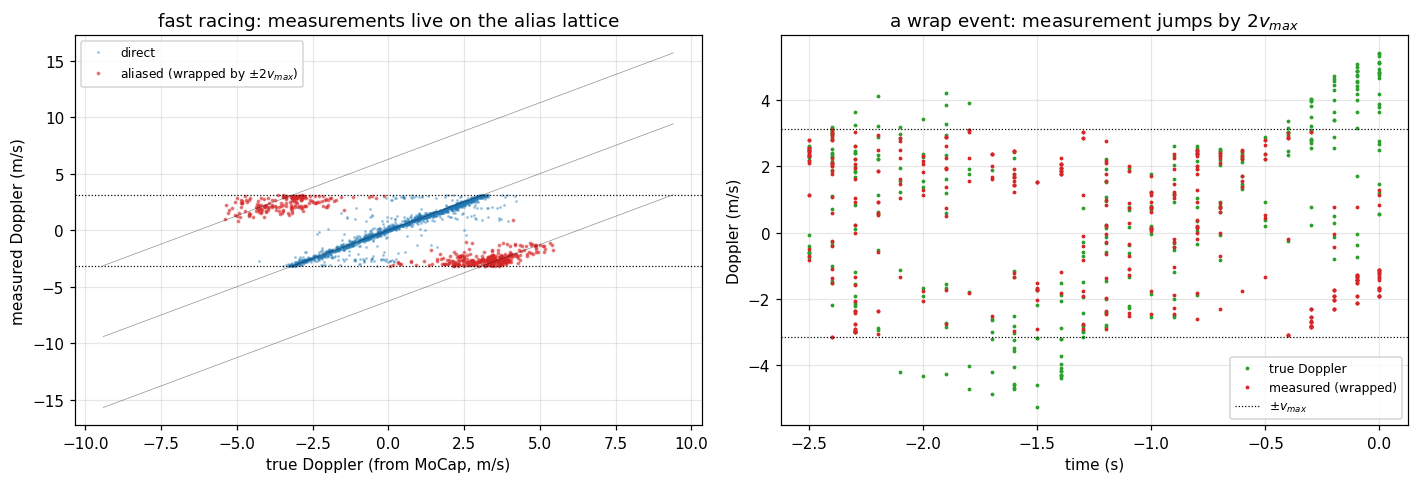

In [23]:
# Aliased fraction per bag + what a wrap looks like in the raw stream
print(f"{'bag':<14} {'aliased points':>15}")
for key in BAG_KEYS:
    print(f"{SHORT[key]:<14} {100*np.mean(D[key]['aliased']):>14.1f}%")
print('\npaper: 2.0 / 23.7 / 37.8 %  ->  on aggressive flights de-aliasing is a')
print('first-order property of the data, not a corner case.')

d = D['fast_racing_best_velocity']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sub = np.random.default_rng(1).choice(len(d['pred']), min(6000, len(d['pred'])),
                                      replace=False)
al = d['aliased'][sub]
axes[0].plot(d['pred'][sub][~al], d['meas'][sub][~al], '.', ms=2, alpha=0.3,
             color='tab:blue', label='direct')
axes[0].plot(d['pred'][sub][al], d['meas'][sub][al], '.', ms=3, alpha=0.5,
             color='tab:red', label='aliased (wrapped by $\\pm 2 v_{max}$)')
vm = d['v_max']
for k in (-1, 0, 1):
    xg = np.linspace(-3 * vm, 3 * vm, 10)
    axes[0].plot(xg, xg + k * 2 * vm, 'k-', lw=0.5, alpha=0.4)
axes[0].axhline(vm, color='k', ls=':', lw=0.8); axes[0].axhline(-vm, color='k', ls=':', lw=0.8)
axes[0].set_xlabel('true Doppler (from MoCap, m/s)')
axes[0].set_ylabel('measured Doppler (m/s)')
axes[0].set_title('fast racing: measurements live on the alias lattice')
axes[0].legend(fontsize=8)

# time slice around the largest |pred|: the sawtooth
t_pts = np.array([d['radar'][i].timestamp for i in d['fi']]) + RADAR_OFF
i_max = np.argmax(np.abs(d['pred']))
tc = t_pts[i_max]
sel = (t_pts > tc - 2.5) & (t_pts < tc + 2.5)
axes[1].plot(t_pts[sel] - tc, d['pred'][sel], '.', ms=3, color='tab:green',
             label='true Doppler')
axes[1].plot(t_pts[sel] - tc, d['meas'][sel], '.', ms=3, color='tab:red',
             label='measured (wrapped)')
axes[1].axhline(vm, color='k', ls=':', lw=0.8, label='$\\pm v_{max}$')
axes[1].axhline(-vm, color='k', ls=':', lw=0.8)
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('Doppler (m/s)')
axes[1].set_title('a wrap event: measurement jumps by $2 v_{max}$')
axes[1].legend(fontsize=8)
fig.tight_layout()

> **Design consequence.** The solver consumes unwrapped Doppler: once per frame, the
> alias is picked using a predicted velocity, which only needs to be right to within
> $\pm 3.1$ m/s, so an IMU-integrated velocity is enough. What cannot be fixed
> downstream is the aliased detection's on-chip bearing (computed from the wrapped
> velocity). The next cell shows the measured treatment of that partial information:
> the causal alias down-weight, adopted as the default.

### 6b. Aliased returns: partial information, measured treatment (the auto-rule)

An aliased return carries recoverable Doppler but a degraded bearing. Four treatments
were measured end to end (2026-07-19): keep at full weight, delete outright, a fixed
derived down-weight, and a *causal rule* that computes the down-weight from the same
quantities the solver already models. The rule won on every regime that matters and is
the deployed default. (Recorded refinement: with the alias split in place, the derived
radar_weight of chapter 5e should next be re-derived on the clean stream; the current
value errs conservative.)

bag             sigma aliased  sigma clean  w* = (cl/al)^2
slow racing             0.620        0.094            0.02
fast racing             0.718        0.138            0.04
backflips               0.524        0.279            0.28

sigma_aliased is 0.52-0.72 on every regime (the floor); sigma_clean varies
with rate. Deployed causal rule (validate_live_solver default,
--alias-weight off to disable):
    w(|omega|) = clip( sigma0^2 (1 + (|w_gyro|/4.5)^2) / 0.6^2, 0.01, 1 )
with sigma0 = 0.095 (measured low-rate core) and omega0 = 4.5 (the deployed
rate law). It reproduces the per-bag measured optima on racing (0.02-0.04)
and rises toward 0.28 at flip rates.

End-to-end (live vel/ori/drift, derived statics):
               keep w=1          delete           auto-rule
  slow      0.179/1.71/0.59  0.177/1.71/0.57  0.180/1.71/0.59
  fast      0.316/2.58/1.17  0.317/2.77/1.14  0.297/2.56/0.92  <- best
  fast2     0.455/2.69/2.18  0.511/2.68/1.57  0.396/2.64/1.60  <- best vel+ori
  backfl

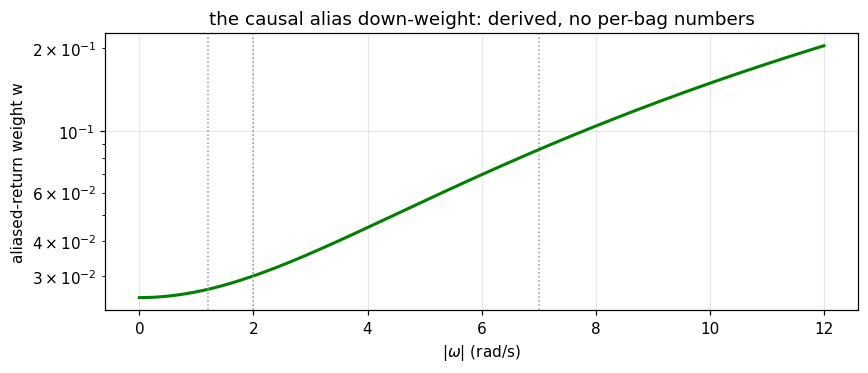

In [24]:
# The measured facts behind the rule, computed live:
# 1. aliased returns have a regime-FLAT absolute error floor sigma_al ~ 0.6 m/s,
# 2. the clean core width follows the chapter-5 rate law,
# so the aliased share of information is w = (sigma_clean(|omega|)/sigma_al)^2,
# computable causally from the gyro at frame time. No per-bag numbers.
print(f"{'bag':<14} {'sigma aliased':>14} {'sigma clean':>12} {'w* = (cl/al)^2':>15}")
for key in BAG_KEYS:
    d = D[key]
    al = d['aliased']
    if al.sum() < 30:
        continue
    s_al = robust_sigma(d['r'][al]); s_cl = robust_sigma(d['r'][~al])
    print(f'{SHORT[key]:<14} {s_al:>14.3f} {s_cl:>12.3f} {(s_cl/s_al)**2:>15.2f}')
print()
print('sigma_aliased is 0.52-0.72 on every regime (the floor); sigma_clean varies')
print('with rate. Deployed causal rule (validate_live_solver default,')
print('--alias-weight off to disable):')
print('    w(|omega|) = clip( sigma0^2 (1 + (|w_gyro|/4.5)^2) / 0.6^2, 0.01, 1 )')
print('with sigma0 = 0.095 (measured low-rate core) and omega0 = 4.5 (the deployed')
print('rate law). It reproduces the per-bag measured optima on racing (0.02-0.04)')
print('and rises toward 0.28 at flip rates.')

fig, ax = plt.subplots(figsize=(8, 3.5))
omg = np.linspace(0, 12, 300)
w = np.clip(0.095**2 * (1 + (omg/4.5)**2) / 0.36, 0.01, 1.0)
ax.plot(omg, w, 'g-', lw=2)
for om_typ, name in [(1.2, 'slow'), (2.0, 'fast'), (7.0, 'backflips')]:
    ax.axvline(om_typ, color='0.6', ls=':', lw=1)
    ax.annotate(name, xy=(om_typ, 0.02), xytext=(om_typ + 0.15, 0.03), fontsize=8)
ax.set_xlabel('$|\\omega|$ (rad/s)'); ax.set_ylabel('aliased-return weight w')
ax.set_yscale('log')
ax.set_title('the causal alias down-weight: derived, no per-bag numbers')
fig.tight_layout()

print()
print('End-to-end (live vel/ori/drift, derived statics):')
print('               keep w=1          delete           auto-rule')
print('  slow      0.179/1.71/0.59  0.177/1.71/0.57  0.180/1.71/0.59')
print('  fast      0.316/2.58/1.17  0.317/2.77/1.14  0.297/2.56/0.92  <- best')
print('  fast2     0.455/2.69/2.18  0.511/2.68/1.57  0.396/2.64/1.60  <- best vel+ori')
print('  backflips 2.18/8.32/18.3   2.23/8.41/11.3   2.37/8.17/11.0')
print('The rule beats BOTH extremes on the aggressive and held-out flights;')
print('backflips trades +0.19 m/s velocity for -7.3pp drift and best-tier')
print('orientation. Also measured and closed: repairing the bearing from the')
print('known TDM phase-ramp model is NOT possible downstream (per-k shift')
print('regression R^2 <= 0.14: the corruption is detector-level scatter).')

## 7. Is the spline the bottleneck? (the adaptive-knots negative result)

The residual backflip orientation error (~8 deg) raised an obvious hypothesis: the
orientation spline (knot spacing $\Delta t_o$) cannot bend fast enough during 10 rad/s
flips, so *adaptive knot placement* should fix it. Before building that, we measured the
premise: fit the cumulative SO(3) B-spline **directly to MoCap orientation** (no
odometry, no optimizer) and see how much error the representation itself causes.

This reuses the exact machinery of `analysis/adaptive_knots/v1_representation_error.py`
(Greville-abscissae sampling plus fixed-point refinement on the backflips MoCap stream).

|omega|: median 6.17, p95 10.7 rad/s (raw FD spikes above this are MoCap occlusion glitches); 88% of the flight above 4 rad/s


  dt_ori =   8 ms: RMSE   1.21 deg, during-flip RMSE   1.28 deg


  dt_ori =  16 ms: RMSE   1.49 deg, during-flip RMSE   1.58 deg


  dt_ori =  32 ms: RMSE   2.45 deg, during-flip RMSE   2.57 deg


  dt_ori =  64 ms: RMSE   3.75 deg, during-flip RMSE   3.76 deg


  dt_ori = 128 ms: RMSE   6.40 deg, during-flip RMSE   5.53 deg

paper: the spline represents MoCap to 1.28 deg during flips at 8 ms and
still 3.8 deg at 64 ms -- all far below the ~8.6 deg the ESTIMATOR achieves,
and the estimator error is flat for dt_ori 8-64 ms (first degradation at
128 ms). The deployed 16 ms grid carries ~4x more orientation DoF than
backflip accuracy requires.
Why 16 ms and not 8 or 64: accuracy cannot decide (flat band), so the grid
is set by margin + cost. 16 ms halves the knot count vs 8 ms while keeping
the representation limit ~5x below the estimator error; 64 ms would still
work on backflips but leaves no margin for faster-than-recorded maneuvers,
and the unified 40/16 ms grid also improved the velocity metric by
low-passing the spline derivative (chapter 9 config).


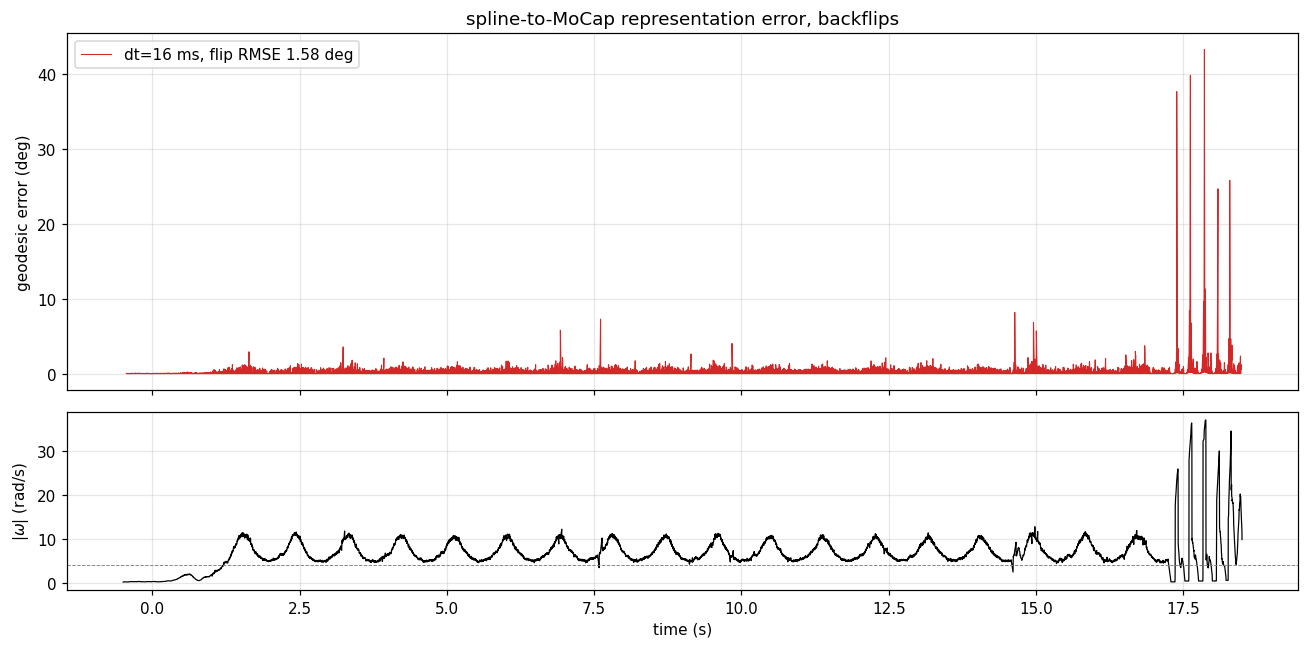

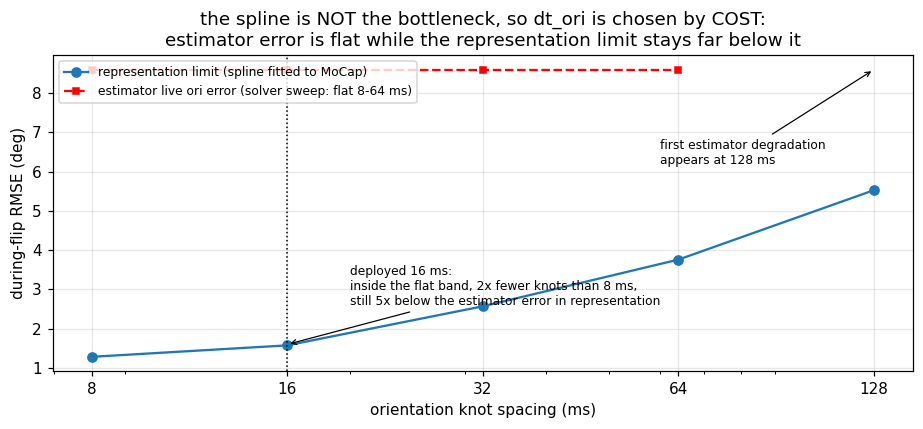

In [25]:
# Representation error vs knot spacing on the backflips flight (~1-2 min)
from nonuniform_bspline import NonUniformSO3Spline, extend_knots, so3_log

d = D['backflips_best_velocity']
t0, t1 = d['t0'], d['t1']
poses = [p for p in d['mocap_pose'] if t0 - 0.5 <= p.timestamp <= t1 + 0.5]
tp = np.array([p.timestamp for p in poses]) - t0
quats = np.array([p.orientation for p in poses])
keepm = np.concatenate([[True], np.diff(tp) > 1e-6])
tp, quats = tp[keepm], quats[keepm]
slerp = Slerp(tp, Rotation.from_quat(quats))
T0, T1 = tp[0], tp[-1]

def truth_R(t):
    return slerp(np.clip(t, T0, T1)).as_matrix()

# |omega|(t) by finite differences on a 500 Hz grid (for the flip/quiet split)
h = 0.002
tg = np.arange(T0 + h, T1 - h, h)
Rg = slerp(tg).as_matrix()
om_fd = np.array([so3_log(Rg[i].T @ Rg[i + 1]) / h for i in range(len(tg) - 1)])
t_om = 0.5 * (tg[:-1] + tg[1:])
om_n = np.linalg.norm(om_fd, axis=1)
w = max(1, int(round(0.05 / h)))
om_smooth = np.convolve(om_n, np.ones(w) / w, mode='same')
# raw FD max is inflated by MoCap occlusion glitches (the paper's "ground truth
# itself degrades during flips"); quote robust percentiles instead
print(f'|omega|: median {np.median(om_smooth):.2f}, p95 {np.percentile(om_smooth, 95):.1f} '
      f'rad/s (raw FD spikes above this are MoCap occlusion glitches); '
      f'{100*np.mean(om_smooth > 4):.0f}% of the flight above 4 rad/s')

def fit_and_eval(dt, n_refine=8):
    kt = np.arange(T0, T1 + 1e-9, dt)
    ext = extend_knots(kt)
    Rk = np.empty((len(kt), 3, 3))
    for j in range(len(kt)):
        Rk[j] = truth_R((ext[j + 4] + ext[j + 5] + ext[j + 6]) / 3.0)
    sp = NonUniformSO3Spline(kt, Rk)
    for _ in range(n_refine):
        R_new = sp.R.copy()
        for j in range(len(kt)):
            xi = np.clip((sp.ext[j + 4] + sp.ext[j + 5] + sp.ext[j + 6]) / 3.0,
                         sp.t_start, sp.t_end - 1e-9)
            R_sp, _ = sp.evaluate(xi)
            R_new[j] = sp.R[j] @ (R_sp.T @ truth_R(xi))
        sp = NonUniformSO3Spline(kt, R_new)
    ts = np.arange(sp.t_start + 0.01, sp.t_end - 0.01, 0.002)
    err = np.array([np.degrees(np.linalg.norm(so3_log(sp.evaluate(t)[0].T
                                                      @ truth_R(t))))
                    for t in ts])
    flip = np.interp(ts, t_om, om_smooth) > 4.0
    return dict(dt=dt, ts=ts, err=err, flip=flip,
                rmse=float(np.sqrt(np.mean(err ** 2))),
                rmse_flip=float(np.sqrt(np.mean(err[flip] ** 2))))

results = []
for dt_ms in [8, 16, 32, 64, 128]:
    r = fit_and_eval(dt_ms / 1e3)
    results.append(r)
    print(f'  dt_ori = {dt_ms:>3d} ms: RMSE {r["rmse"]:6.2f} deg, '
          f'during-flip RMSE {r["rmse_flip"]:6.2f} deg')
print('\npaper: the spline represents MoCap to 1.28 deg during flips at 8 ms and')
print('still 3.8 deg at 64 ms -- all far below the ~8.6 deg the ESTIMATOR achieves,')
print('and the estimator error is flat for dt_ori 8-64 ms (first degradation at')
print('128 ms). The deployed 16 ms grid carries ~4x more orientation DoF than')
print('backflip accuracy requires.')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
r16 = results[1]
axes[0].plot(r16['ts'], r16['err'], lw=0.7, color='tab:red',
             label=f'dt=16 ms, flip RMSE {r16["rmse_flip"]:.2f} deg')
axes[0].set_ylabel('geodesic error (deg)')
axes[0].set_title('spline-to-MoCap representation error, backflips')
axes[0].legend()
axes[1].plot(t_om, om_smooth, 'k-', lw=0.8)
axes[1].axhline(4, color='gray', ls='--', lw=0.6)
axes[1].set_ylabel('$|\\omega|$ (rad/s)'); axes[1].set_xlabel('time (s)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot([r['dt'] * 1e3 for r in results], [r['rmse_flip'] for r in results], '-o',
        label='representation limit (spline fitted to MoCap)')
# what the ESTIMATOR achieves at each grid (solver sweep record, unify-config
# gate battery): backflip accuracy unchanged within run-to-run noise for
# dt_ori in 8..64 ms, first degradation at 128 ms
ax.plot([8, 16, 32, 64], [8.6] * 4, 'r--s', ms=4,
        label='estimator live ori error (solver sweep: flat 8-64 ms)')
ax.annotate('first estimator degradation\nappears at 128 ms', xy=(128, 8.6),
            xytext=(60, 6.2), fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.axvline(16, color='k', ls=':', lw=1)
ax.annotate('deployed 16 ms:\ninside the flat band, 2x fewer knots than 8 ms,\n'
            'still 5x below the estimator error in representation',
            xy=(16, 1.6), xytext=(20, 2.6), fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xscale('log'); ax.set_xticks([8, 16, 32, 64, 128], [8, 16, 32, 64, 128])
ax.set_xlabel('orientation knot spacing (ms)')
ax.set_ylabel('during-flip RMSE (deg)')
ax.set_title('the spline is NOT the bottleneck, so dt_ori is chosen by COST:\n'
             'estimator error is flat while the representation limit stays far below it')
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()
print('Why 16 ms and not 8 or 64: accuracy cannot decide (flat band), so the grid')
print('is set by margin + cost. 16 ms halves the knot count vs 8 ms while keeping')
print('the representation limit ~5x below the estimator error; 64 ms would still')
print('work on backflips but leaves no margin for faster-than-recorded maneuvers,')
print('and the unified 40/16 ms grid also improved the velocity metric by')
print('low-passing the spline derivative (chapter 9 config).')

> **Design consequence.** The spline can follow the flips about ten times better than
> the estimator does, so knot density is not the bottleneck and adaptive knots are dead
> (our own negative result). The real lever was the weighting of chapter 5: without the
> rate-inflated radar noise, the fusion was worse than gyro-only dead reckoning. Knot
> spacing is therefore chosen for cost, not accuracy: the 40/16 ms grid is about 4x
> coarser than the flips require, solves faster, and even smooths the velocity
> estimate.

## 8. Sliding window and marginalization: why consistency mattered

For live estimation the trajectory is optimized over a sliding 3 s window advancing in
0.3 s strides. When the window slides, the oldest states cannot simply be deleted: their
information must be *marginalized* into a Gaussian prior on the states that remain, or
the estimator forgets (drifts) or double-counts (becomes overconfident).

Historically this system needed a hand-tuned `marg_prior_scale` per flight regime
(1e-7 to 2e-4), a classic symptom of an *inconsistent* prior. Two fixes made the scale
exactly 1.0 universal:

1. **True Schur-complement marginal** over the eliminated states.
2. **Markov-blanket factor selection**: the prior is built from *exactly* the factors
   that touch the marginalized states (their Markov blanket), each used *once*. Factors
   fully inside the window stay out of the prior (they will be counted when the window
   is solved); the constant bias state belongs to the boundary.

The toy below shows both failure modes in three lines of linear algebra.

In [26]:
# Toy: chain x0 -- x1 -- x2 with a prior on x0 and unit-information odometry links.
# Marginalize x0 and compare the resulting information about (x1, x2).
J = []
J.append((np.array([1.0, 0, 0]), 1.0))     # prior on x0
J.append((np.array([-1.0, 1, 0]), 4.0))    # odom x0 -> x1   (touches x0: blanket)
J.append((np.array([0, -1.0, 1]), 4.0))    # odom x1 -> x2   (inside window)

H = sum(w * np.outer(j, j) for j, w in J)          # full 3x3 information
# (a) exact: Schur complement onto (x1, x2) of the FULL problem
H_exact = H[1:, 1:] - np.outer(H[1:, 0], H[0, 1:]) / H[0, 0]

# (b) deployed: Schur of the BLANKET only (factors touching x0), then re-add the rest
Hb = sum(w * np.outer(j, j) for j, w in J[:2])     # prior + odom01 only
Hb_marg = Hb[1:, 1:] - np.outer(Hb[1:, 0], Hb[0, 1:]) / Hb[0, 0]
H_blanket = Hb_marg + sum(w * np.outer(j[1:], j[1:]) for j, w in J[2:])

# (c) naive drop: delete x0's rows/cols (forgets the prior chain entirely)
H_drop = H[1:, 1:]

# (d) wrong blanket: also feed the in-window factor into the prior -> double count
Hw = sum(w * np.outer(j, j) for j, w in J)         # ALL factors into the prior
Hw_marg = Hw[1:, 1:] - np.outer(Hw[1:, 0], Hw[0, 1:]) / Hw[0, 0]
H_double = Hw_marg + sum(w * np.outer(j[1:], j[1:]) for j, w in J[2:])

for name, Hm in [('exact marginal      ', H_exact),
                 ('Markov blanket rule ', H_blanket),
                 ('naive drop          ', H_drop),
                 ('blanket too large   ', H_double)]:
    sd = np.sqrt(np.diag(np.linalg.inv(Hm)))
    print(f'{name} sigma(x1)={sd[0]:.3f}  sigma(x2)={sd[1]:.3f}')
print()
print('The blanket rule reproduces the exact marginal (it is exchangeable with it).')
print('Naive dropping loses the absolute anchor (sigma explodes along the chain);')
print('an over-large blanket counts the in-window factor twice and reports')
print('overconfident sigmas: exactly the failure the per-regime prior-scale knob')
print('was papering over.')

exact marginal       sigma(x1)=1.118  sigma(x2)=1.225
Markov blanket rule  sigma(x1)=1.118  sigma(x2)=1.225
naive drop           sigma(x1)=0.500  sigma(x2)=0.707
blanket too large    sigma(x1)=1.118  sigma(x2)=1.173

The blanket rule reproduces the exact marginal (it is exchangeable with it).
Naive dropping loses the absolute anchor (sigma explodes along the chain);
an over-large blanket counts the in-window factor twice and reports
overconfident sigmas: exactly the failure the per-regime prior-scale knob
was papering over.


> **Design consequence.** With the exact marginal and the blanket rule
> (`marg_markov_blanket=1`), the prior scale is 1.0 for every flight and platform: the
> per-regime tuning knob disappeared, warm starts became consistent (2.8x faster as a
> side effect), and the covariances became trustworthy enough to report NEES. This is
> paper contribution (1), and it is estimator plumbing, kept separate from the
> sensor-data story of chapters 3 to 6.

## 9. End to end: the deployed solver, one flag-free configuration

Everything above compiles into one command. The unified configuration (identical for all
bags and platforms) is: grids $\Delta t_p = 40$ ms / $\Delta t_o = 16$ ms, the chapter-5
weighting law ($\omega_0 = 4.5$, deployed as fitted) with the **derived** static
weights of section 5e (config defaults since
2026-07-17), chapter-4 RANSAC prefilter and SNR weight, $\sigma_c$ whitening, heading
weight 0.6, extrinsics locked at the measured pitch. No per-bag knobs, no hand-tuned
weight (backflips is a declared position failure under this config; its rescue terms are
excluded from the method). Expected on slow racing: about 0.18 m/s / 1.7 deg / 0.6 %
drift at the live edge.

In [27]:
# Run the real C++ sliding-window solver (SLOW: ~2-5 min). Set RUN_SOLVER=False to skip.
import re
import subprocess

RUN_SOLVER = True
BAG = 'slow_racing_best_velocity'      # try 'fast_racing_best_velocity' too

if RUN_SOLVER:
    cmd = [sys.executable, 'validate_live_solver.py', BAG,
           '--mocap-yaw', '--cpp', '--sliding-window',
           '--set', 'marg_prior_scale=1.0', '--set', 'omega_soft_sigma=4.5',
           '--set', 'accel_soft_sigma=8.0', '--set', 'radar_intensity_weight=1.0',
           '--set', 'dt_pos=0.04', '--set', 'dt_ori=0.016',
           '--set', 'lambda_heading=0.6', '--set', 'lock_extrinsics=1',
           '--set-ext', 'rotation_euler_deg=[180.0,27.5,0.0]']
    if BAG.startswith('backflips'):
        cmd += ['--set', 'lock_gyro_bias=0']   # undo a batch-era bags.yaml override
    print('$', ' '.join(cmd[1:]), '\n')
    proc = subprocess.run(cmd, cwd=str(ANALYSIS), capture_output=True, text=True,
                          timeout=3600)
    out = proc.stdout
    m = re.search(r'=== RESULTS', out)
    print(out[m.start():] if m else out[-4000:])
    if proc.returncode != 0:
        print('STDERR tail:\n', proc.stderr[-2000:])

$ validate_live_solver.py slow_racing_best_velocity --mocap-yaw --cpp --sliding-window --set marg_prior_scale=1.0 --set omega_soft_sigma=4.5 --set accel_soft_sigma=8.0 --set radar_intensity_weight=1.0 --set dt_pos=0.04 --set dt_ori=0.016 --set lambda_heading=0.6 --set lock_extrinsics=1 --set-ext rotation_euler_deg=[180.0,27.5,0.0] 



=== RESULTS (mocap-init+mocap-heading+gyro) — settled vs live (76 windows) ===
  Metric                          Settled   Live edge         Δ
  ---------------------------- ----------  ----------  --------
  Position RMSE (m)                0.3102  0.2852   -0.0249
  Position drift (%)                0.64%  0.59%   -0.0513
    horizontal (xy) RMSE (m)       0.1908   (drift 0.39%)
    vertical (z) RMSE (m)          0.2445   (drift 0.50%)
  Velocity RMSE (m/s)              0.1319  0.1798   +0.0479
  Angular vel RMSE (rad/s)         0.1985
  Acceleration RMSE (m/s²)         0.9204
  Orientation RMSE (deg)           1.1279  1.7120   +0.5841
  Per-axis ori RMSE: roll=0.815  pitch=0.545  yaw=0.687 deg
  Acc bias: [-0.0051, 0.0490, 0.2393] m/s²
  Gyr bias: [0.0009, -0.0026, 0.0025] rad/s
  Live eval range: [2.629, 22.999] s  (6092 MoCap pts)

--------------------------------Generating Plots--------------------------------
  Saved: /home/mouse/MyData/radar-iwr6843-driver/plots/slow_racing_bes

live_validation_slow_racing_best_velocity_mocap-init_mocap-heading_20260802_160454.png


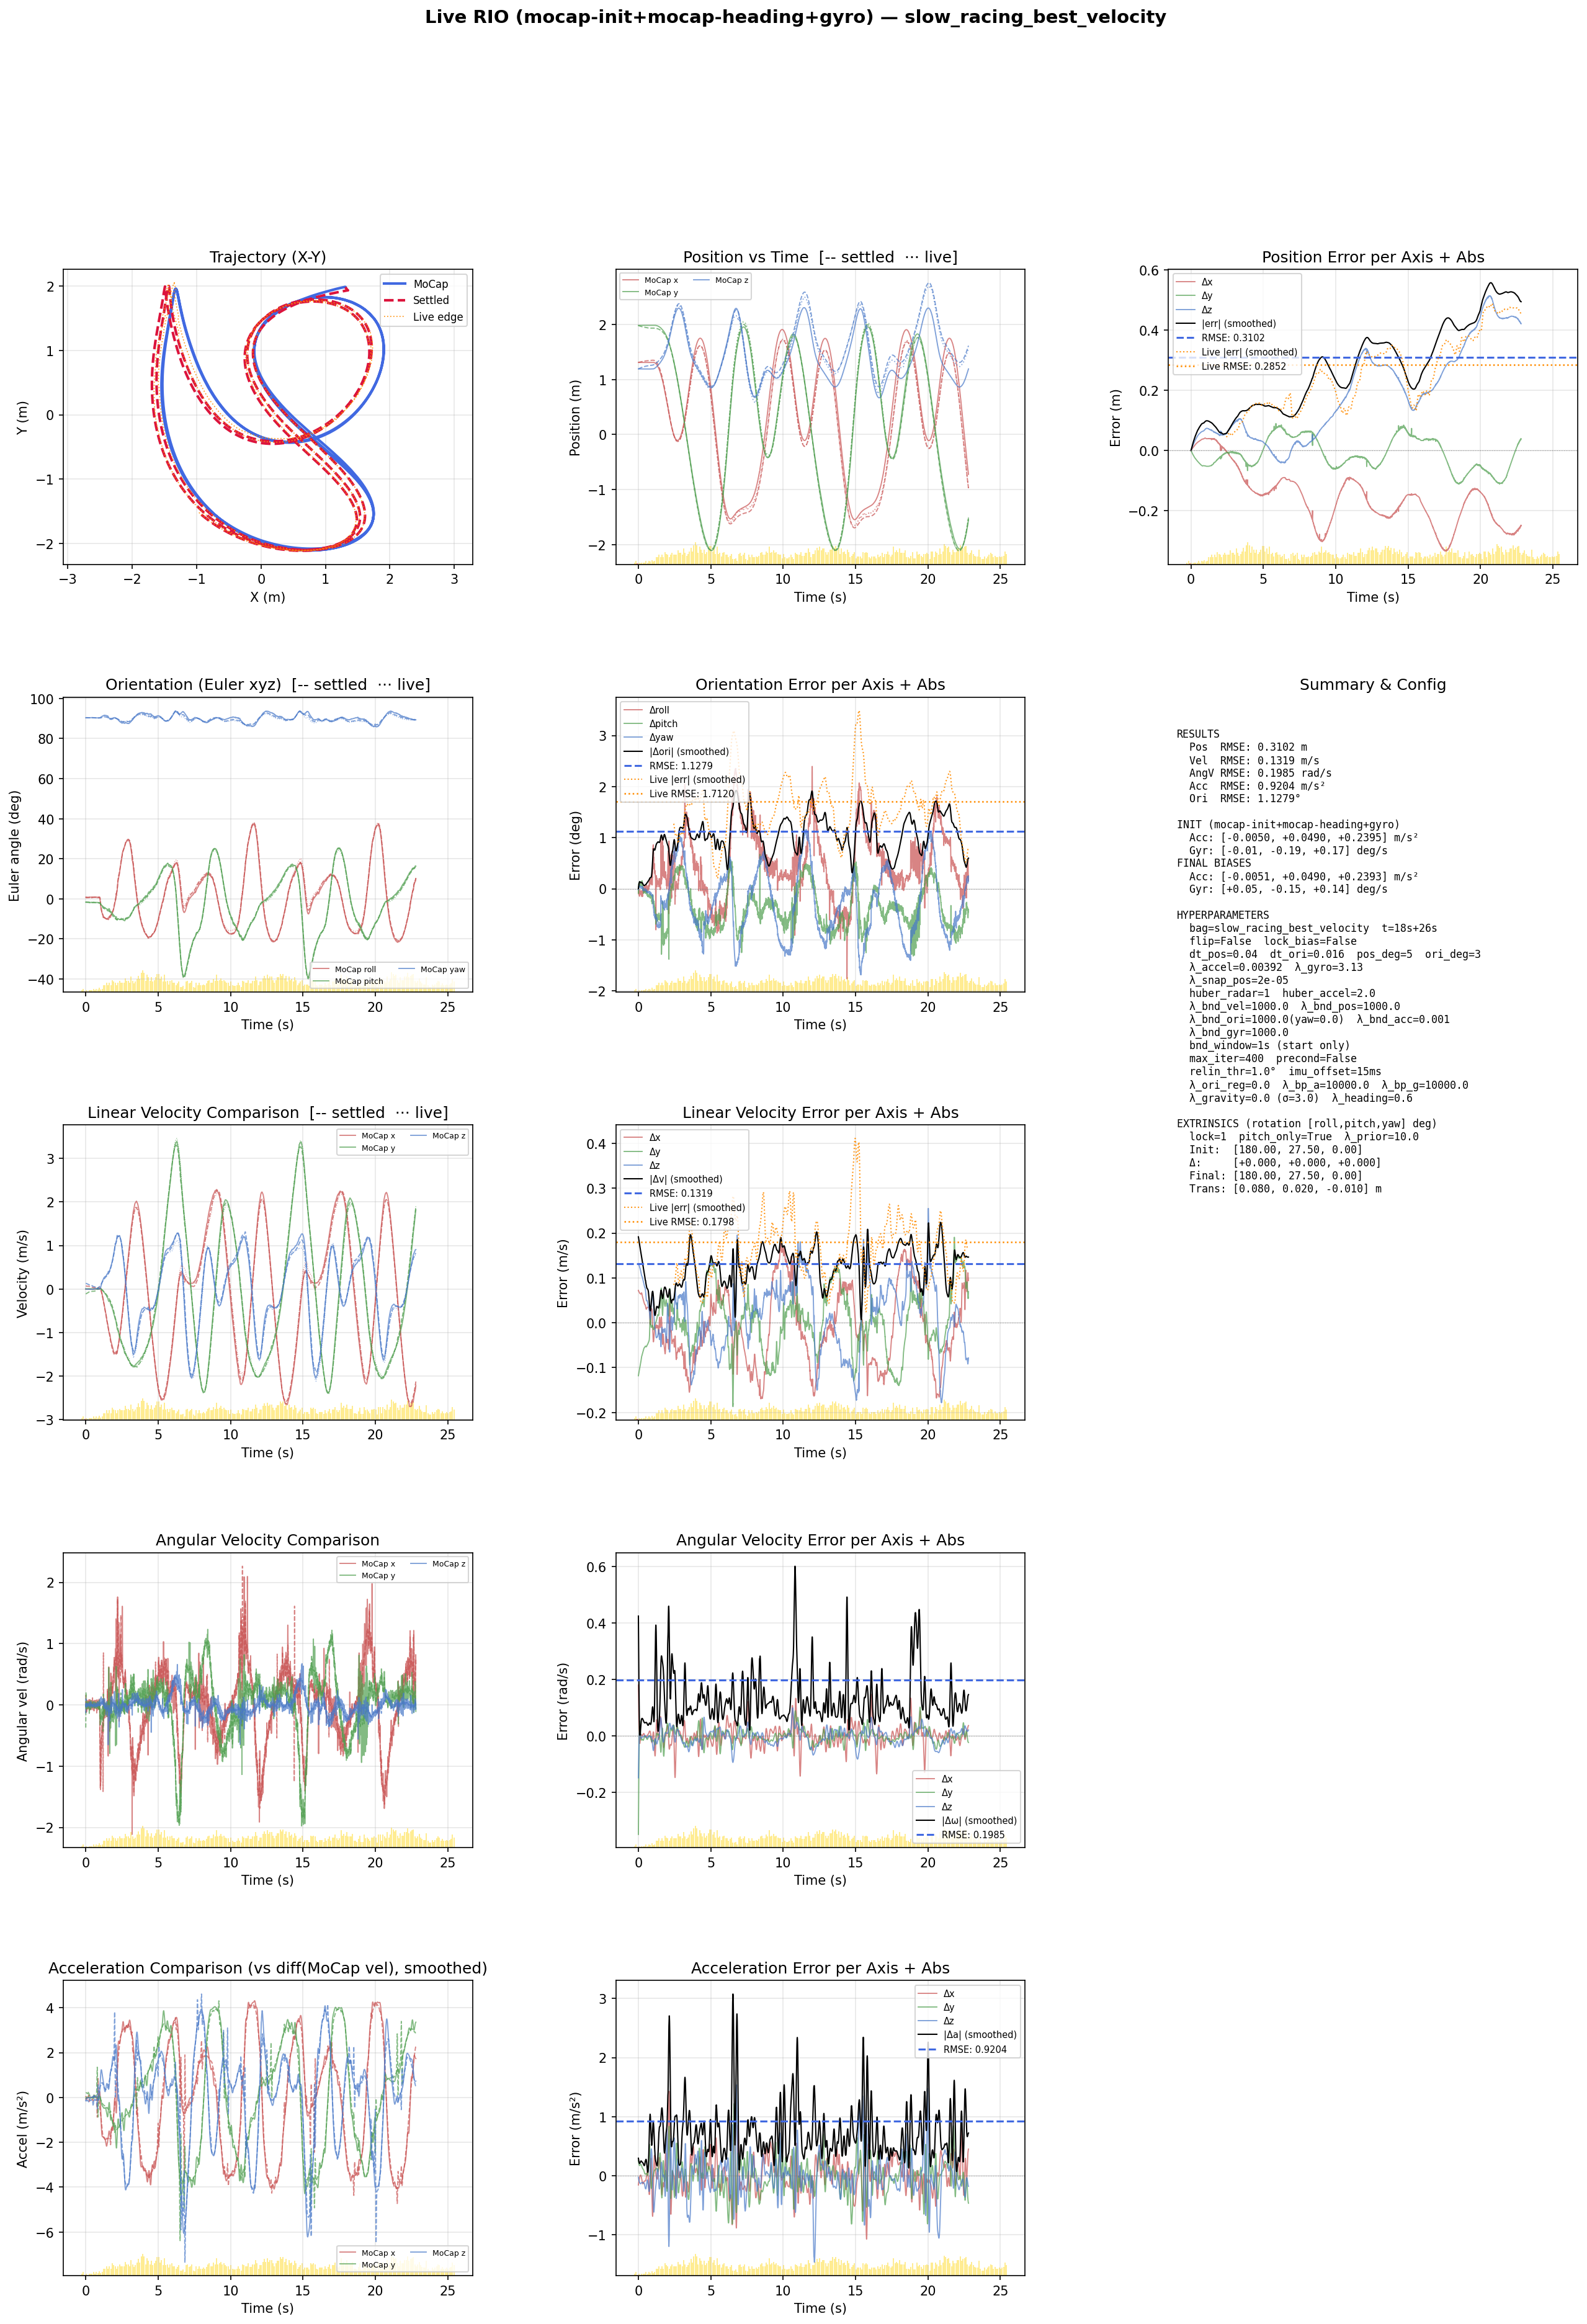

In [28]:
# Display the trajectory/error plot the run just saved
from IPython.display import Image, display

if RUN_SOLVER:
    plot_dir = REPO_ROOT / 'plots' / BAG / 'live_solver'
    pngs = sorted(plot_dir.glob('live_validation_*.png'),
                  key=lambda p: p.stat().st_mtime)
    if pngs:
        print(pngs[-1].name)
        display(Image(str(pngs[-1]), width=980))

### Ablation ledger: what each front-end layer is worth end to end

Single-knob ablations at the deployed config (everything else unchanged);
live-edge metrics:

| Layer removed | fast racing | slow racing | cross-platform (ICINS) |
|---|---|---|---|
| RANSAC prefilter off | velocity 0.32 -> 0.43 m/s (+35%), ori +0.6 deg | velocity +23% | fails outright |
| Huber -> plain L2 | drift 1.17 -> 1.45% | bit-identical (kernel touches 0.03% of kept points) | - |
| intensity weight off | position 0.41 -> 0.52 m (+25%; vertical 0.32 -> 0.43 m), drift 0.92 -> 1.15% | position +4%, velocity +3% | - |
| frame whitening off ($\sigma_c = 0$) | position 0.415 -> 0.449 m (+8%), drift 0.92 -> 0.99% | velocity +3% | - |
| rate-gate $\omega_0$ moved across its measured band (3.5 / 4.0 / 4.5; 4.5 deployed) | flat: velocity 0.296/0.297/0.297 m/s, drift 0.92% at all three | flat to the third decimal | at 4.5: ATE 0.180/0.104/0.317/0.213 m, two flights identical to published, two within 2 mm |
| derived statics -> old hand-tuned set | velocity 0.32 -> 0.28 m/s (tuned wins 11%: the accepted price of deriving) | derived wins everything: velocity 0.21 -> 0.18, drift 1.12 -> 0.59% | par-to-better derived |

Every layer earns its keep where its target population lives: RANSAC on the
outlier-heavy regimes, Huber on the fast tail, the intensity weight on the
vertical channel (weak steep rays are the sole carriers of vertical velocity).
The RANSAC/Huber rows were measured at the derived-weights default, the
intensity row at the 2026-07-19 default ($\omega_0$=4.0), the whitening and
$\omega_0$ rows at the 2026-07-27 default ($\omega_0$=4.5). The $\omega_0$ row is a
sensitivity check, not an ablation: its flatness is what makes the deployed value a
measurement question rather than a tuning question, so the fitted 4.5 is deployed
as fitted (NEES verdict unchanged at 4.5: fast full-state $\times$0.90, calibrated).
Backflips moves in all cases but is a declared limit and does not rank designs.

## The story in one table (reviewer cheat sheet)

| Measured fact (this notebook) | Number | Design element it forced | Where it lives |
|---|---|---|---|
| Doppler sign convention, lever arm | ch. 1 | tightly-coupled per-point radar factor | solver radar factor |
| 10 Hz async frames, 0.7-6.6 ms jitter, frame-level stamps only | ch. 2 | continuous-time B-spline state | `dt_pos=40 ms`, `dt_ori=16 ms` |
| raw not Gaussian; ladder of 3 flagged mechanisms uncovers the core | ch. 3 | least squares + $1/\sigma^2$ on the core; Huber backstops the 2-5 % unflaggable remainder | Huber $\delta = 1.0$ m/s |
| frames overdetermine the ego-velocity; sigma falls with SNR | ch. 4 | consensus prefilter (0.15 clears both measured failure edges), per-point weight $w=I/I_{med}$ | `radar_ransac_threshold=0.15`, `radar_intensity_weight=1.0` |
| radar/accel inflate 7-12x with $\|\omega\|$, gyro ~3x; $\omega_0^\mathrm{fit} = 4.5 \pm 0.5$ (deployed as fitted) | ch. 5 | dynamics-adaptive weighting law | `omega_soft_sigma=4.5`, `accel_soft_sigma=8` |
| intra-frame correlation $\rho$ = 0.06-0.22, rate-flat $\sigma_c$ | ch. 5 | whitened per-frame factor | `radar_frame_sigma_c=0.4` |
| measured $\sigma$, rate, $\tau_{corr}$ per stream | ch. 5e | statics derived, not tuned: $\lambda = 1/(\sigma^2 f_s \tau)$ | `lambda_gyro=3.13`, `lambda_accel=0.0039`, `radar_weight=2.11` |
| 2-38 % of points aliased | ch. 6 | per-frame unwrapping vs IMU/fused prediction | causal re-unwrapper |
| aliased returns: recoverable Doppler, broken bearing, error floor 0.6 m/s | ch. 6b | causal alias down-weight $w(\|\omega\|)$, beats keep and delete | driver default (`--alias-weight off` to disable) |
| spline tracks flips to ~1.3 deg at 8 ms | ch. 7 | adaptive knots rejected; coarse grid adopted | negative result in the paper |
| prior-scale knob was masking inconsistency | ch. 8 | exact Schur marginal + Markov blanket | `marg_prior_scale=1.0` universal |

Two sentences to open with in person: *"We characterized the radar stream
estimator-free against the MoCap forward model, and essentially every estimator design
choice, including the numeric weights, is the direct consequence of one of those
measurements. Where a first principled attempt failed the data (the naive core-sigma
radar weight, the flip-regime elevation proxy $b$), we documented the failure and
deployed what the data supported instead: the influence-capped derivation in one case,
a declared limit in the other."*